In [1]:
import h5py
from sipyco import pyon
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import os as os
import sys

sys.path.append(
    "/home/ae19663/artiq"
)  # Adjust this path to the parent directory of 'repository'
from repository.imaging.processor import AbsImage  # noqa: E402


# it will take folder(scan path) path as input and return sorted list of h5 files DIRECTORY
# the files are sorted based on the numeric part of their names, which is before the first hyphen '-'.
# For example, if the files are named like "000001234-AbsorptionImageExpFrag.h5",
# the sorting will be based on the numeric part "000001234".


folder_directory = (
    "../results/2026-07-01/14/"  # Example directory path, adjust as needed
)
file_names = os.listdir(folder_directory)

# this will print the file names in the directory
print(f"Files in directory: {file_names}")


# Enter the name of the file you want to analyze, this file consisit of many runs of of particular scan parameter if you have multiple runs
particular_directory = (
    folder_directory + "000026160-AbsorptionImageExpFrag.h5"
)  # Example file path, adjust as needed


class EXTRACTOR:
    def __init__(self, artiq_folder_directory, folder_directory, particular_directory):
        self.artiq_folder_directory = artiq_folder_directory
        self.folder_directory = folder_directory
        self.particular_directory = particular_directory
        self.files_directory = EXTRACTOR.sorted_files(folder_directory)

    def list_h5_files(self):
        """
        List all .h5 files in the artiq folder directory.
        """
        file_names = os.listdir(self.folder_directory)
        # calculate how many files are there in the directory
        num_files = len(file_names)
        print(f"Number of files in the directory: {num_files}")
        return [f for f in file_names if f.endswith(".h5")], num_files

    def sorted_files(directory):
        """
        Sort files in the given directory based on the numeric part of their names.
        """
        files = os.listdir(directory)
        file_num = []
        file_name = []

        for i in files:
            # Split the file name into two parts and sort by the numeric part
            file_num.append(i.split("-")[0])
            file_name.append(i.split("-")[1])

        # Sort the files based on the numeric part
        file_num, file_name = zip(*sorted(zip(file_num, file_name)))

        # Recombine the file number and file name into a single list
        sorted_files_list = [f"{num}-{name}" for num, name in zip(file_num, file_name)]

        # Directory list for the files using the sorted file names
        files_directory = [
            os.path.join(directory, f) for f in sorted_files_list if f.endswith(".h5")
        ]

        # Example usage:
        # directory = "../results/2025-07-08/21/"
        # files_directory = sorted_files(directory)

        return files_directory

    def get_override_args(file_directory, hide_defaults=True):
        vals = {}

        f1 = h5py.File(file_directory, "r")
        args = pyon.decode(f1["expid"][()])["arguments"]
        for k, v in args.items():
            if k == "ndscan_params":
                params = pyon.decode(args["ndscan_params"])
                overrides = params["overrides"]
                for k, v in overrides.items():
                    spec = params["schemata"][k]["spec"]
                    val = v[0]["value"]
                    default = type(val)(params["schemata"][k]["default"])
                    if hide_defaults and val == default:
                        continue
                    vals[k] = [val / spec.get("scale", 1), spec.get("unit", "")]
            else:
                vals[k] = [v, ""]
        return vals

    vals = get_override_args(particular_directory, hide_defaults=False)

    def args_names_and_vals(vals):
        # Print arguments names and their values
        args_names = []
        args_vals = []
        for k, (v, unit) in vals.items():
            # print(f"{k} = {v} {unit}")
            args_names.append(k)
            args_vals.append(v)
        return args_names, args_vals

    files_directory = sorted_files(folder_directory)
    # print(files_directory)

    matching_args = []
    for i in range(len(files_directory)):
        # print(f"File {i + 1}: {files_directory[i]}")
        vals1 = get_override_args(files_directory[i])
        args_name1, args_val1 = args_names_and_vals(vals1)
        for j in range(len(files_directory)):
            vals2 = get_override_args(files_directory[j])
            args_name2, args_val2 = args_names_and_vals(vals2)
            if args_name1 == args_name2:
                # print(f"Matching arguments found for {files_directory[i]} and {files_directory[j]}")
                matching_args.append((files_directory[i], files_directory[j]))
            else:
                # print(f"No matching arguments for {files_directory[i]} and {files_directory[j]}")
                pass

    # plot the absorption image of the particular run in the scan, it is still a work in progress not working properly
    def plot_absorption_image(file_directory, run_number):
        f1 = h5py.File(file_directory, "r")
        if run_number == 0:
            a = 0
        else:
            a = run_number * 3
        image_0 = "Images.All" + "." + str(a)
        image_1 = "Images.All" + "." + str(a + 1)
        image_2 = "Images.All" + "." + str(a + 2)

        absimg = AbsImage(
            data=f1["datasets"][image_0][()],
            ref=f1["datasets"][image_1][()],
            bg=f1["datasets"][image_2][()],
            magnification=0.25,  # Set default magnification
        )
        absimg.plot()
        # plt.show()

    scan_number = 5  # Example scan number, adjust as needed

    # plot_absorption_image(particular_directory, scan_number)
    # Extracting the values and the units from the files
    f1 = h5py.File(files_directory[0], "r")
    a = f1["datasets"]

    # Extracting the values and the units from the files
    f1 = h5py.File(files_directory[0], "r")
    a = f1["datasets"]
    # print(f"Keys in the datasets: {list(a.keys())}")


file_number = 3


class Extractor_file(EXTRACTOR):
    def __init__(self, file_number):
        self.particular_directory = particular_directory
        self.file_number = file_number

        if self.file_number < 0 or self.file_number >= len(self.files_directory):
            raise ValueError(
                f"File number {self.file_number} is out of range. Please choose a number between 0 and {len(self.files_directory) - 1}."
            )

        # Extracting the values and the units from the files
        f1 = h5py.File(self.files_directory[self.file_number], "r")
        # extract file name and run number from the file path

        file_name = os.path.basename(self.files_directory[self.file_number])
        run_number = int(file_name.split("-")[0])
        c = "ndscan.rid_" + str(run_number) + ".point.info"
        d = "ndscan.rid_" + str(run_number) + ".point.axis_0"

        import re  # Ensure re is imported

        a = f1["datasets"][c][()]

        peakx = []
        peaky = []
        centroidx = []
        centroidy = []
        wavelength = []
        atom_number = []
        A = []
        sx = []
        sy = []
        x0 = []
        y0 = []
        records = [a] if isinstance(a, bytes) else a
        for i in range(len(records)):
            # decode if bytes, otherwise use as is
            if isinstance(records[i], bytes):
                decoded = records[i].decode("utf-8")
                lines = decoded.split("\n")
            else:
                lines = a[i]

            for line in lines:
                b = line.strip(",").split(":")
                key = b[0].strip().strip('"')
                if key == "wavelength":
                    wavelength.append(float(b[1]))
                elif key == "atom_number":
                    atom_number.append(float(b[1]))
                elif key == "peak_pixel":  # Assuming this is a key for peak pixels
                    # extract numbers from tuple string
                    tuple_str = ":".join(b[1:]).strip()
                    nums = re.findall(r"[-+]?\d*\.\d+|\d+", tuple_str)
                    if len(nums) >= 3:
                        peakx.append(float(nums[1]))
                        peaky.append(float(nums[0]))
                        # If you want the third value, use float(nums[2])
                    # else skip or handle error
                elif (
                    key == "centroid_pixel"
                ):  # Assuming this is a key for centroid pixels
                    tuple_str = ":".join(b[1:]).strip()
                    nums = re.findall(r"[-+]?\d*\.\d+|\d+", tuple_str)
                    if len(nums) >= 3:
                        centroidx.append(float(nums[1]))
                        centroidy.append(float(nums[0]))
                        # If you want the third value, use float(nums[2])
                elif (
                    key == "best_values_pixel"
                ):  # Assuming this is a key for some values
                    # Extract dictionary from line
                    match = re.search(r"\{(.+?)\}", line)
                    if match:
                        dict_str = match.group(1)
                        items = dict_str.split(",")
                        for item in items:
                            item = item.strip()
                            if ":" in item:
                                key_part, value_part = item.split(":", 1)
                                key_item = key_part.strip().strip("'")
                                value_str = value_part.strip()
                                # Convert to float or int
                                if "." in value_str or "e" in value_str:
                                    value = float(value_str)
                                else:
                                    value = int(value_str)
                                # Append to the correct list
                                if key_item == "A":
                                    A.append(value)
                                elif key_item == "x0":
                                    x0.append(value)
                                elif key_item == "y0":
                                    y0.append(value)
                                elif key_item == "sx":
                                    sx.append(value)
                                elif key_item == "sy":
                                    sy.append(value)
                                elif key_item == "theta":
                                    if not hasattr(self, "theta"):
                                        self.theta = []
                                    self.theta.append(value)
                                elif key_item == "z0":
                                    if not hasattr(self, "z0"):
                                        self.z0 = []
                                    self.z0.append(value)

        # extract scan parameters from the file
        #scan_params = f1["datasets"][d][()]
        # add more decimal places to scan params

        # print(scan_params)

        # list contents in datasets
        datasets = list(f1["datasets"].keys())
        # print("Datasets in the file:", datasets)

        # print the extracted values
        #print file number and file name
        print(f"File Number: {self.file_number}")
        print(f"File Name: {self.files_directory[self.file_number]}")
        print("Wavelength:", wavelength)
        print("Atom Number:", atom_number)
        print("Peak X:", peakx)
        print("Peak Y:", peaky)
        print("Centroid X:", centroidx)
        print("Centroid Y:", centroidy)
        print("A:", A)
        print("Sx:", sx)
        print("Sy:", sy)
        print("X0:", x0)
        print("Y0:", y0)

        # store everything in the csv file also scan parameters
        self.data = {
            "wavelength": wavelength,
            "atom_number": atom_number,
            "peakx": peakx,
            "peaky": peaky,
            "centroidx": centroidx,
            "centroidy": centroidy,
            "A": A,
            "sx": sx,
            "sy": sy,
            "x0": x0,
            "y0": y0,
            #"scan_params": scan_params,
        }

        self.datasets = datasets
    
    print("Data extraction complete.")

Files in directory: ['000025954-AbsorptionImageExpFrag.h5', '000025956-AbsorptionImageExpFrag.h5', '000025953-AbsorptionImageExpFrag.h5', '000025955-AbsorptionImageExpFrag.h5']


FileNotFoundError: [Errno 2] Unable to open file (unable to open file: name = '../results/2026-07-01/14/000026160-AbsorptionImageExpFrag.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

File Number: 0
File Name: ../results/2026-02-11/14/000019549-AbsorptionImageExpFrag.h5
Wavelength: [7.8024602089e-07]
Atom Number: [153682.86265943214]
Peak X: [597.0]
Peak Y: [44.0]
Centroid X: [605.0]
Centroid Y: [46.0]
A: [0.9497962568611141]
Sx: [460.0320145643174]
Sy: [7.670465365366917]
X0: [658.1337399382164]
Y0: [45.23434517989706]
File Number: 1
File Name: ../results/2026-02-11/14/000019550-AbsorptionImageExpFrag.h5
Wavelength: [7.8024602089e-07]
Atom Number: [166379.5201944934]
Peak X: [597.0]
Peak Y: [44.0]
Centroid X: [599.0]
Centroid Y: [47.0]
A: [1.0226230327972567]
Sx: [457.26083646038717]
Sy: [7.730182521879568]
X0: [641.6738637764201]
Y0: [45.67205311845471]
File Number: 2
File Name: ../results/2026-02-11/14/000019551-AbsorptionImageExpFrag.h5
Wavelength: [7.8024602089e-07]
Atom Number: [170345.3640076916]
Peak X: [596.0]
Peak Y: [46.0]
Centroid X: [591.0]
Centroid Y: [47.0]
A: [1.0410115023952669]
Sx: [459.18247937325754]
Sy: [7.745699816230887]
X0: [620.2850222457394

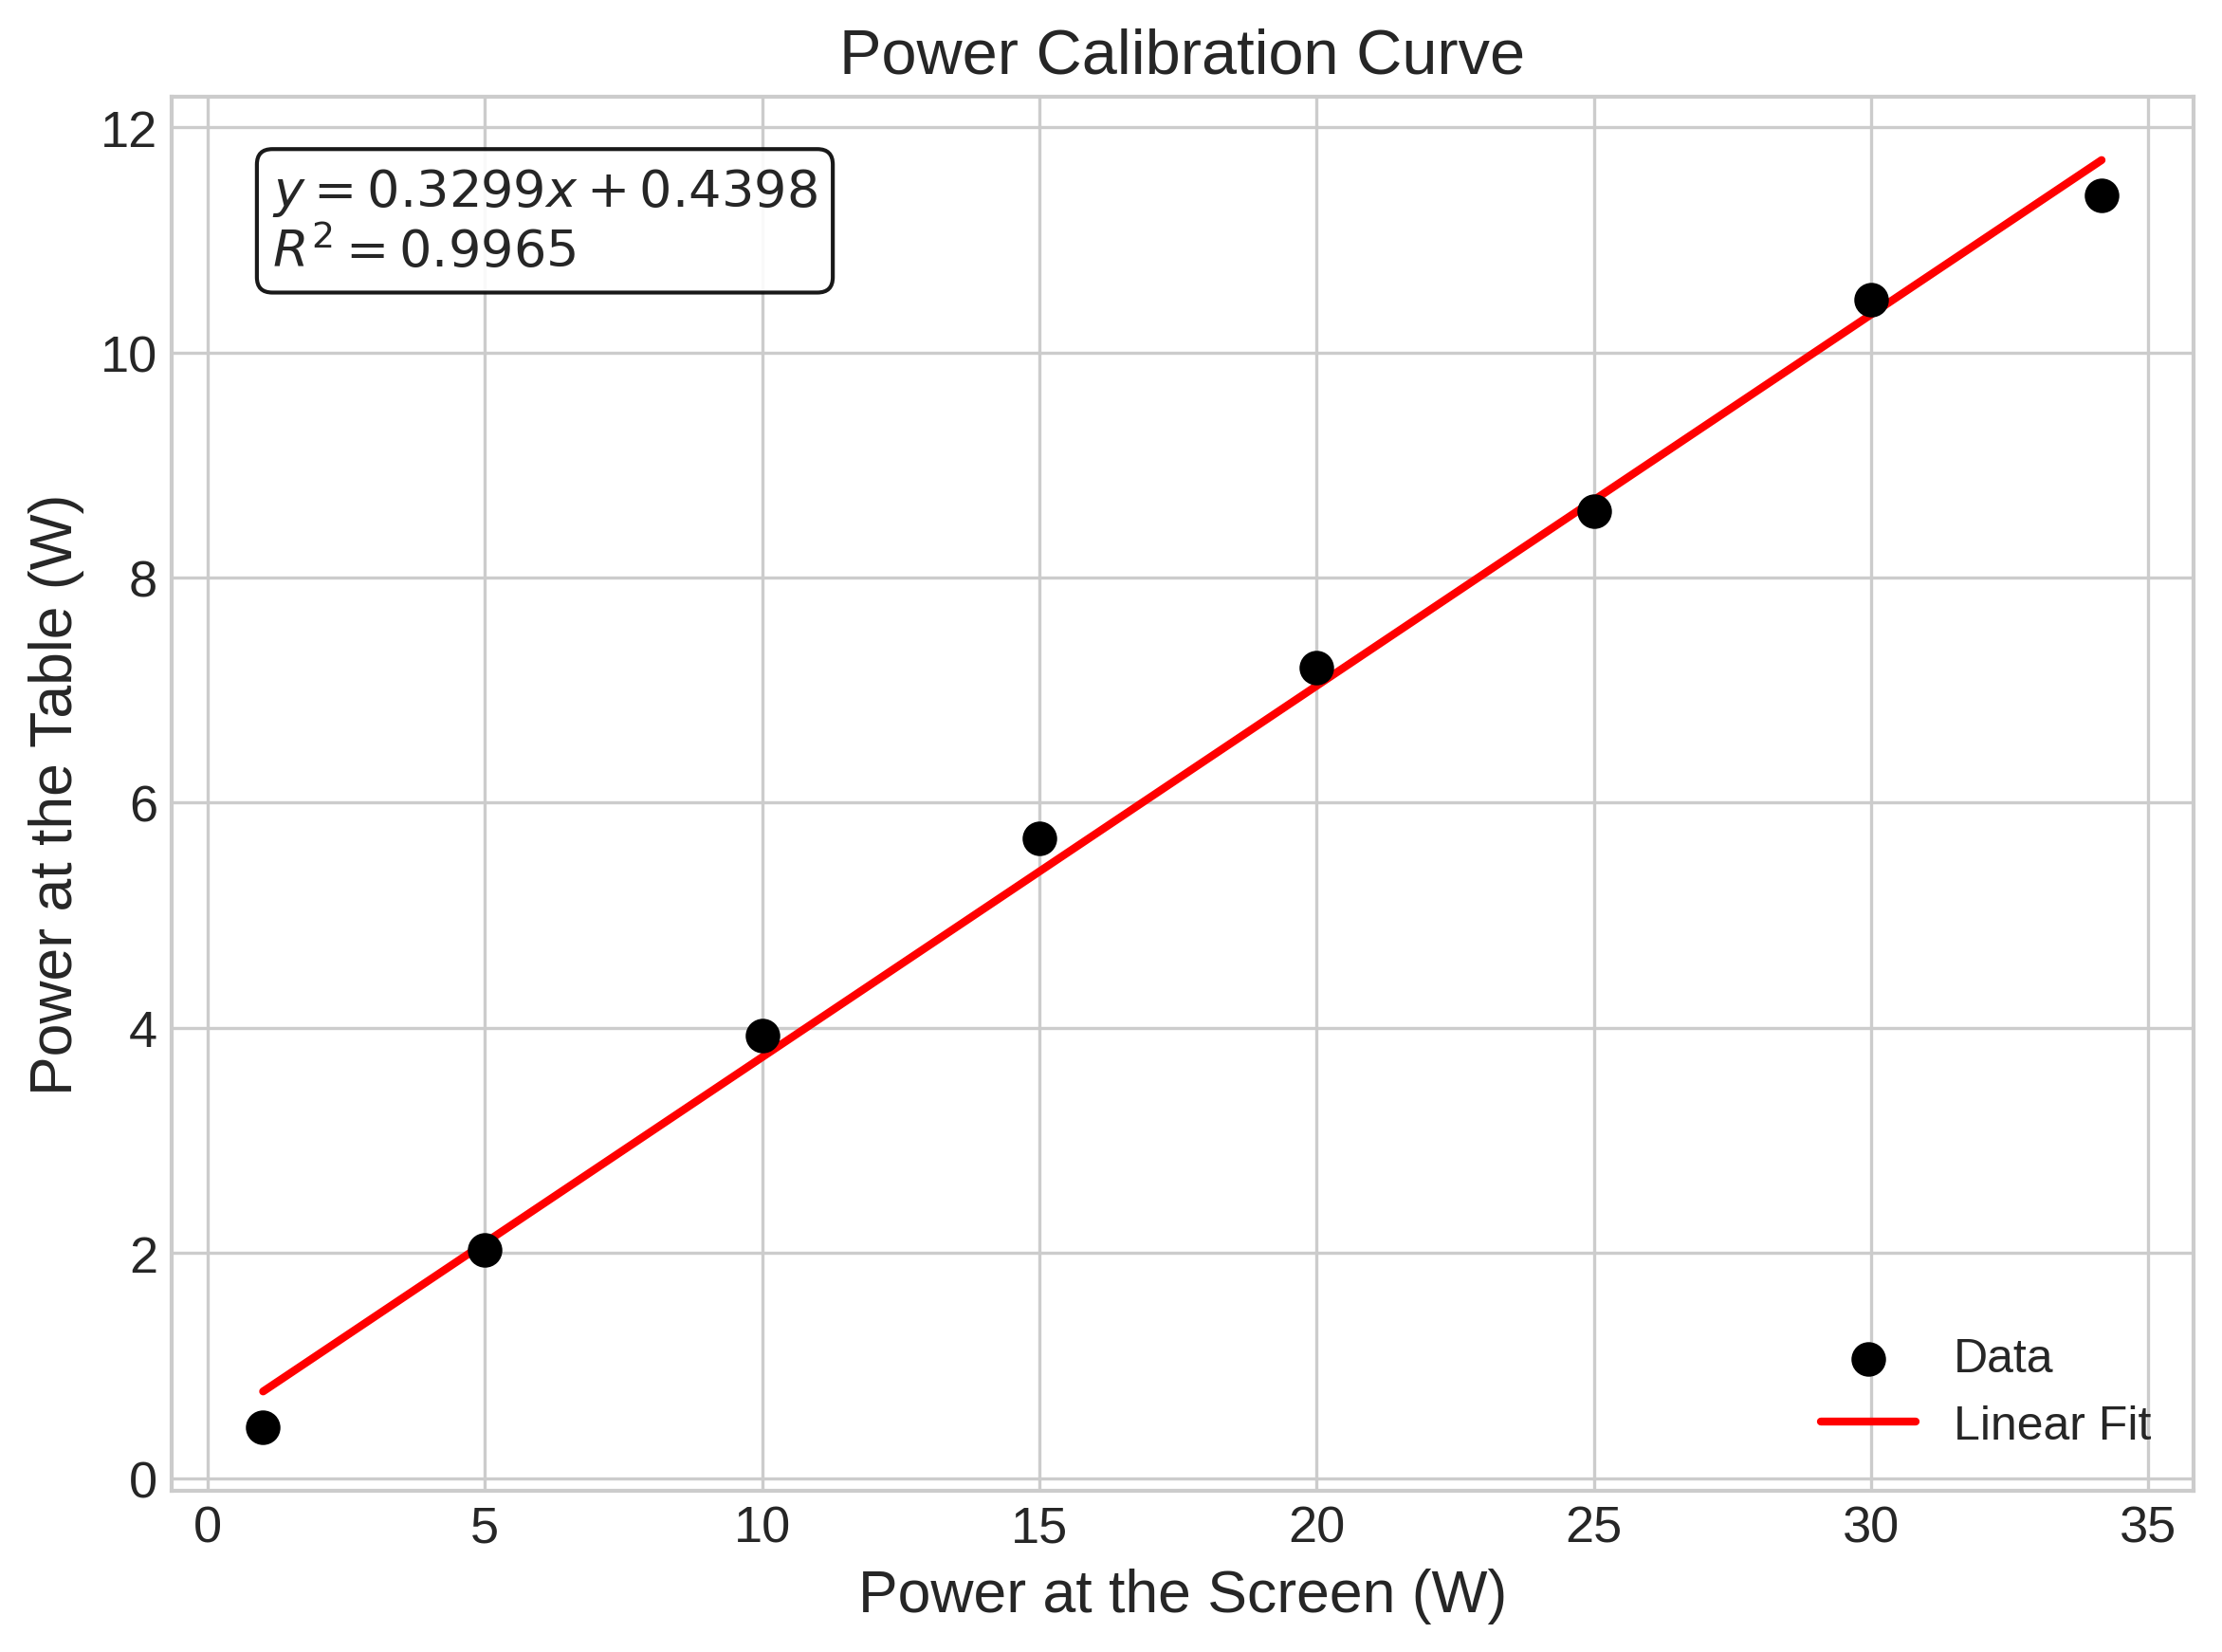

Peak X Means: [545.4545454545455], Peak X Stds: [98.58394082420196]
Centroid X Means: [577.8181818181819], Centroid X Stds: [14.044204122038657]
Centroid Y Means: [46.90909090909091], Centroid Y Stds: [0.2874797872880344]
X0 Means: [575.7278146545585], X0 Stds: [48.03681546811768]
Y0 Means: [46.04920186209539], Y0 Stds: [0.4176929534388324]
Peak Y Means: [45.18181818181818], Peak Y Stds: [1.4024771473219555]
Size of Peak X Set: 11
Size of Power Calibrated Set: 11


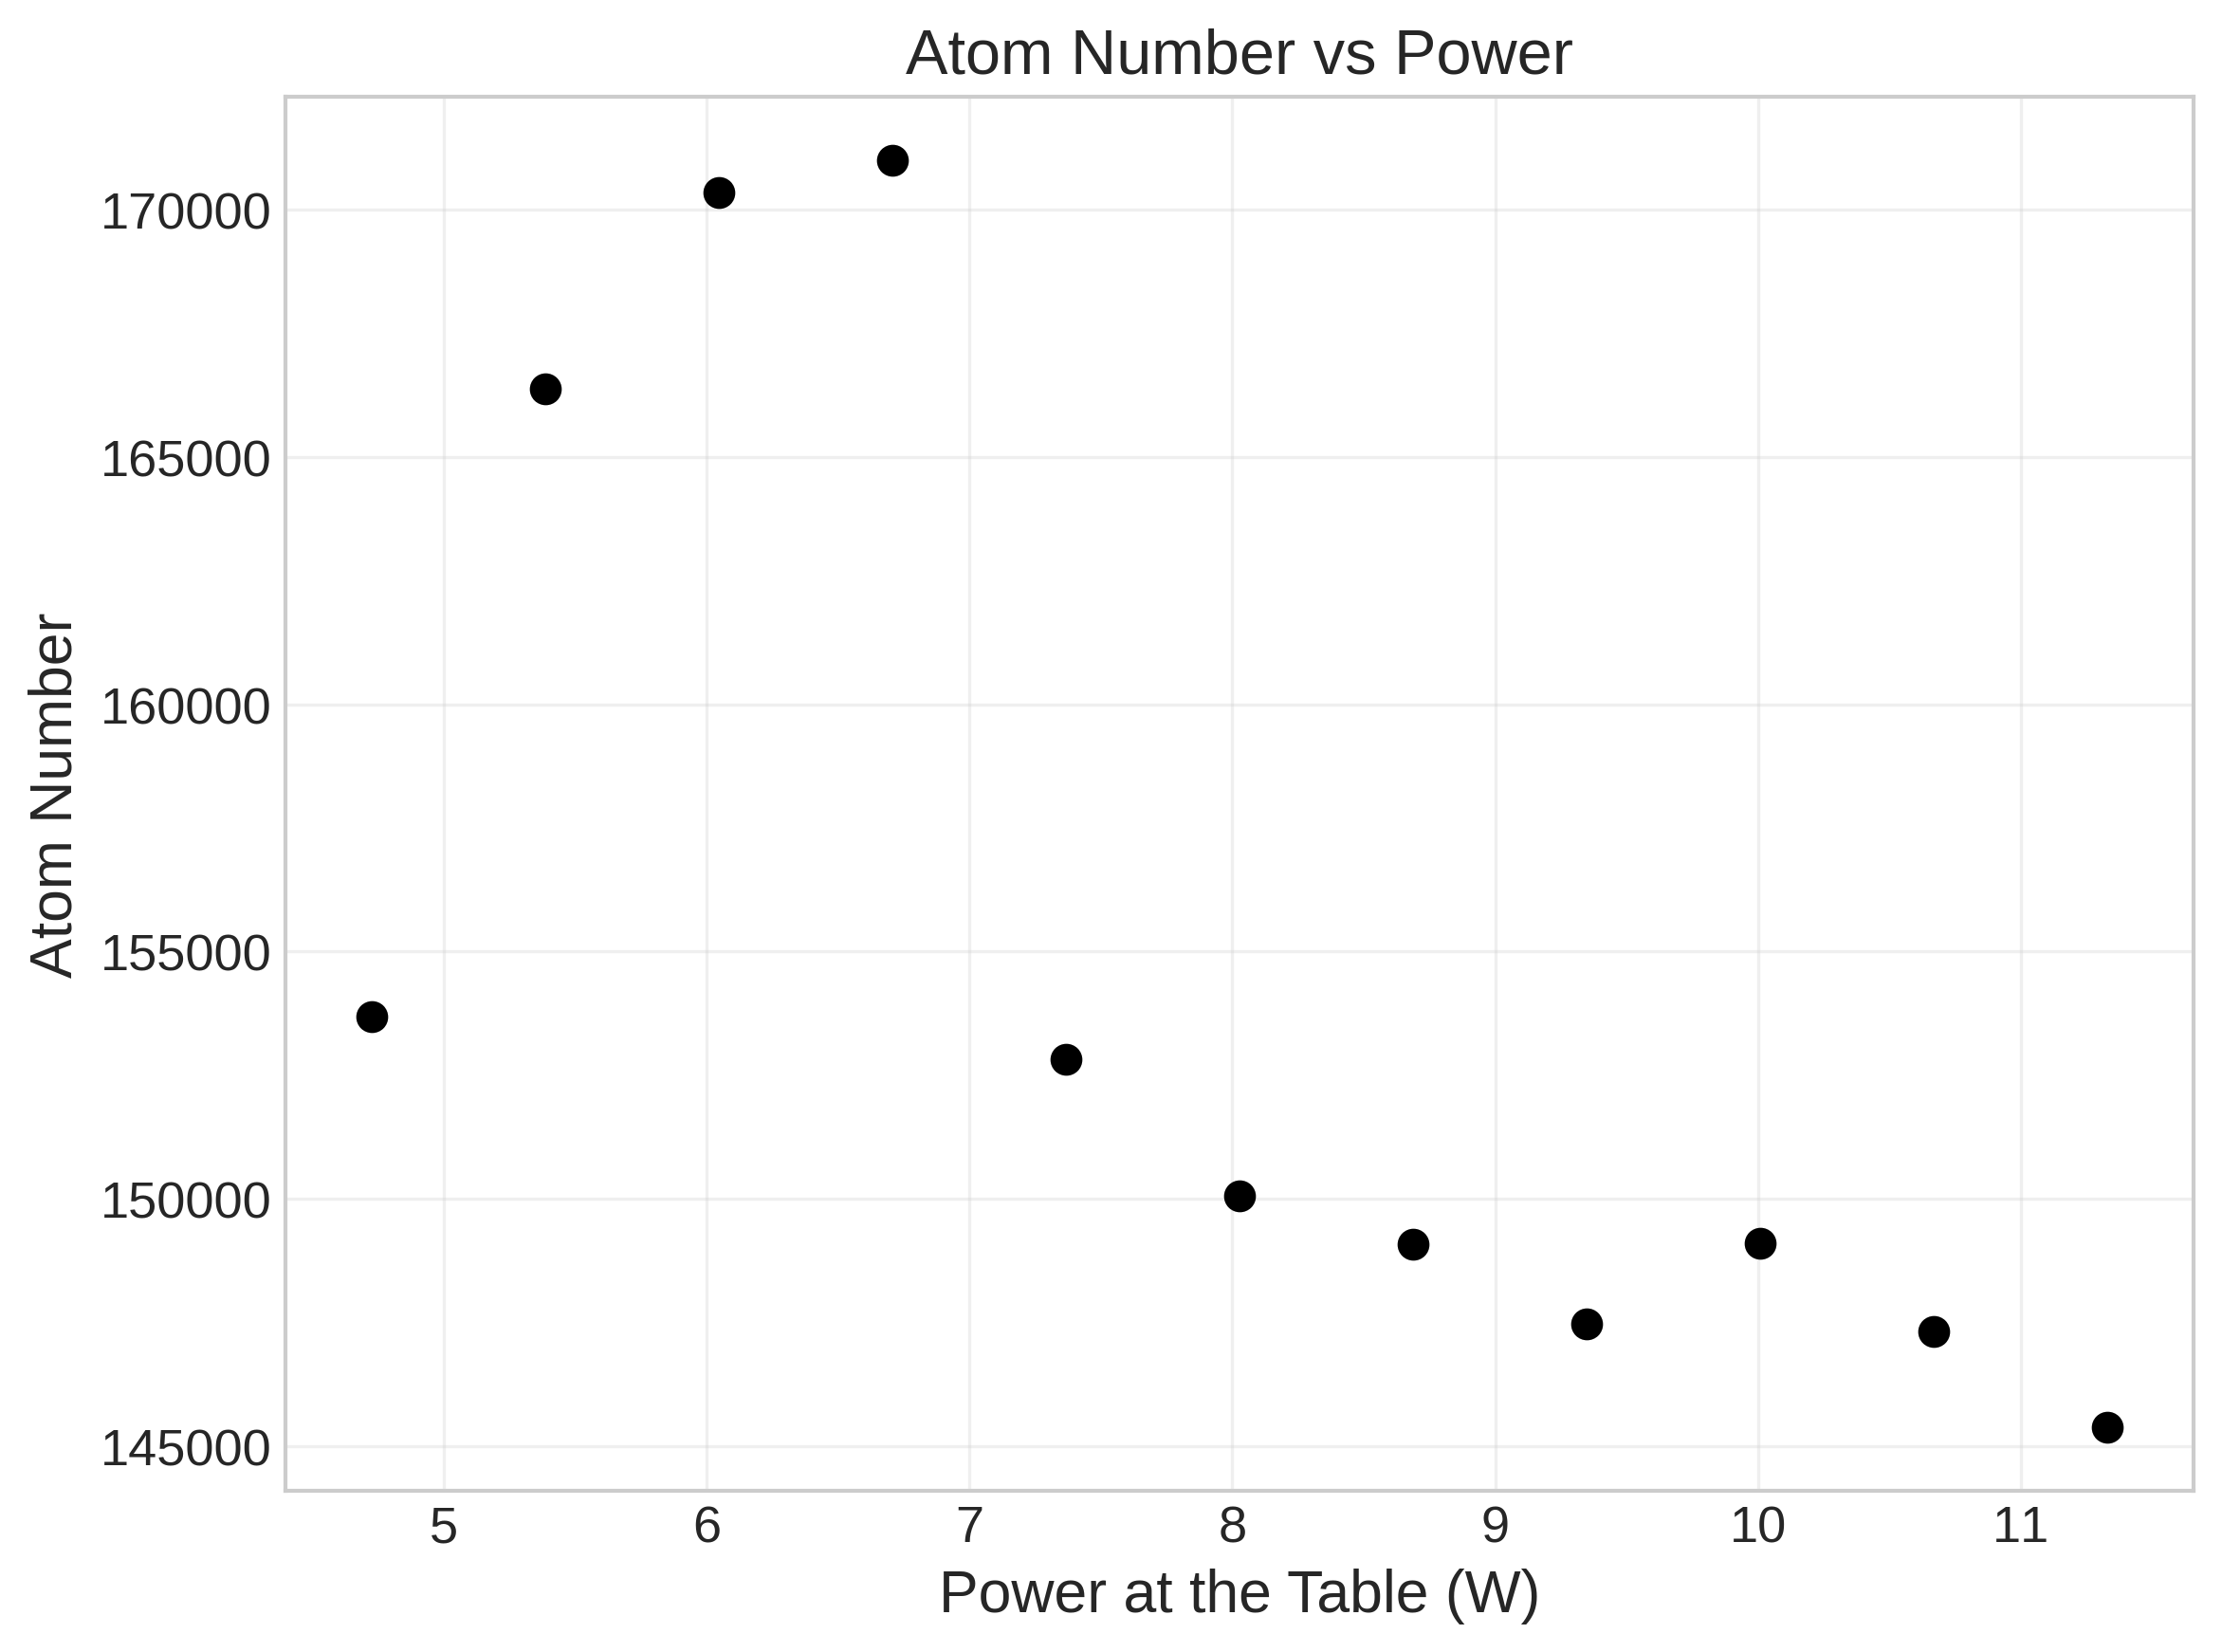

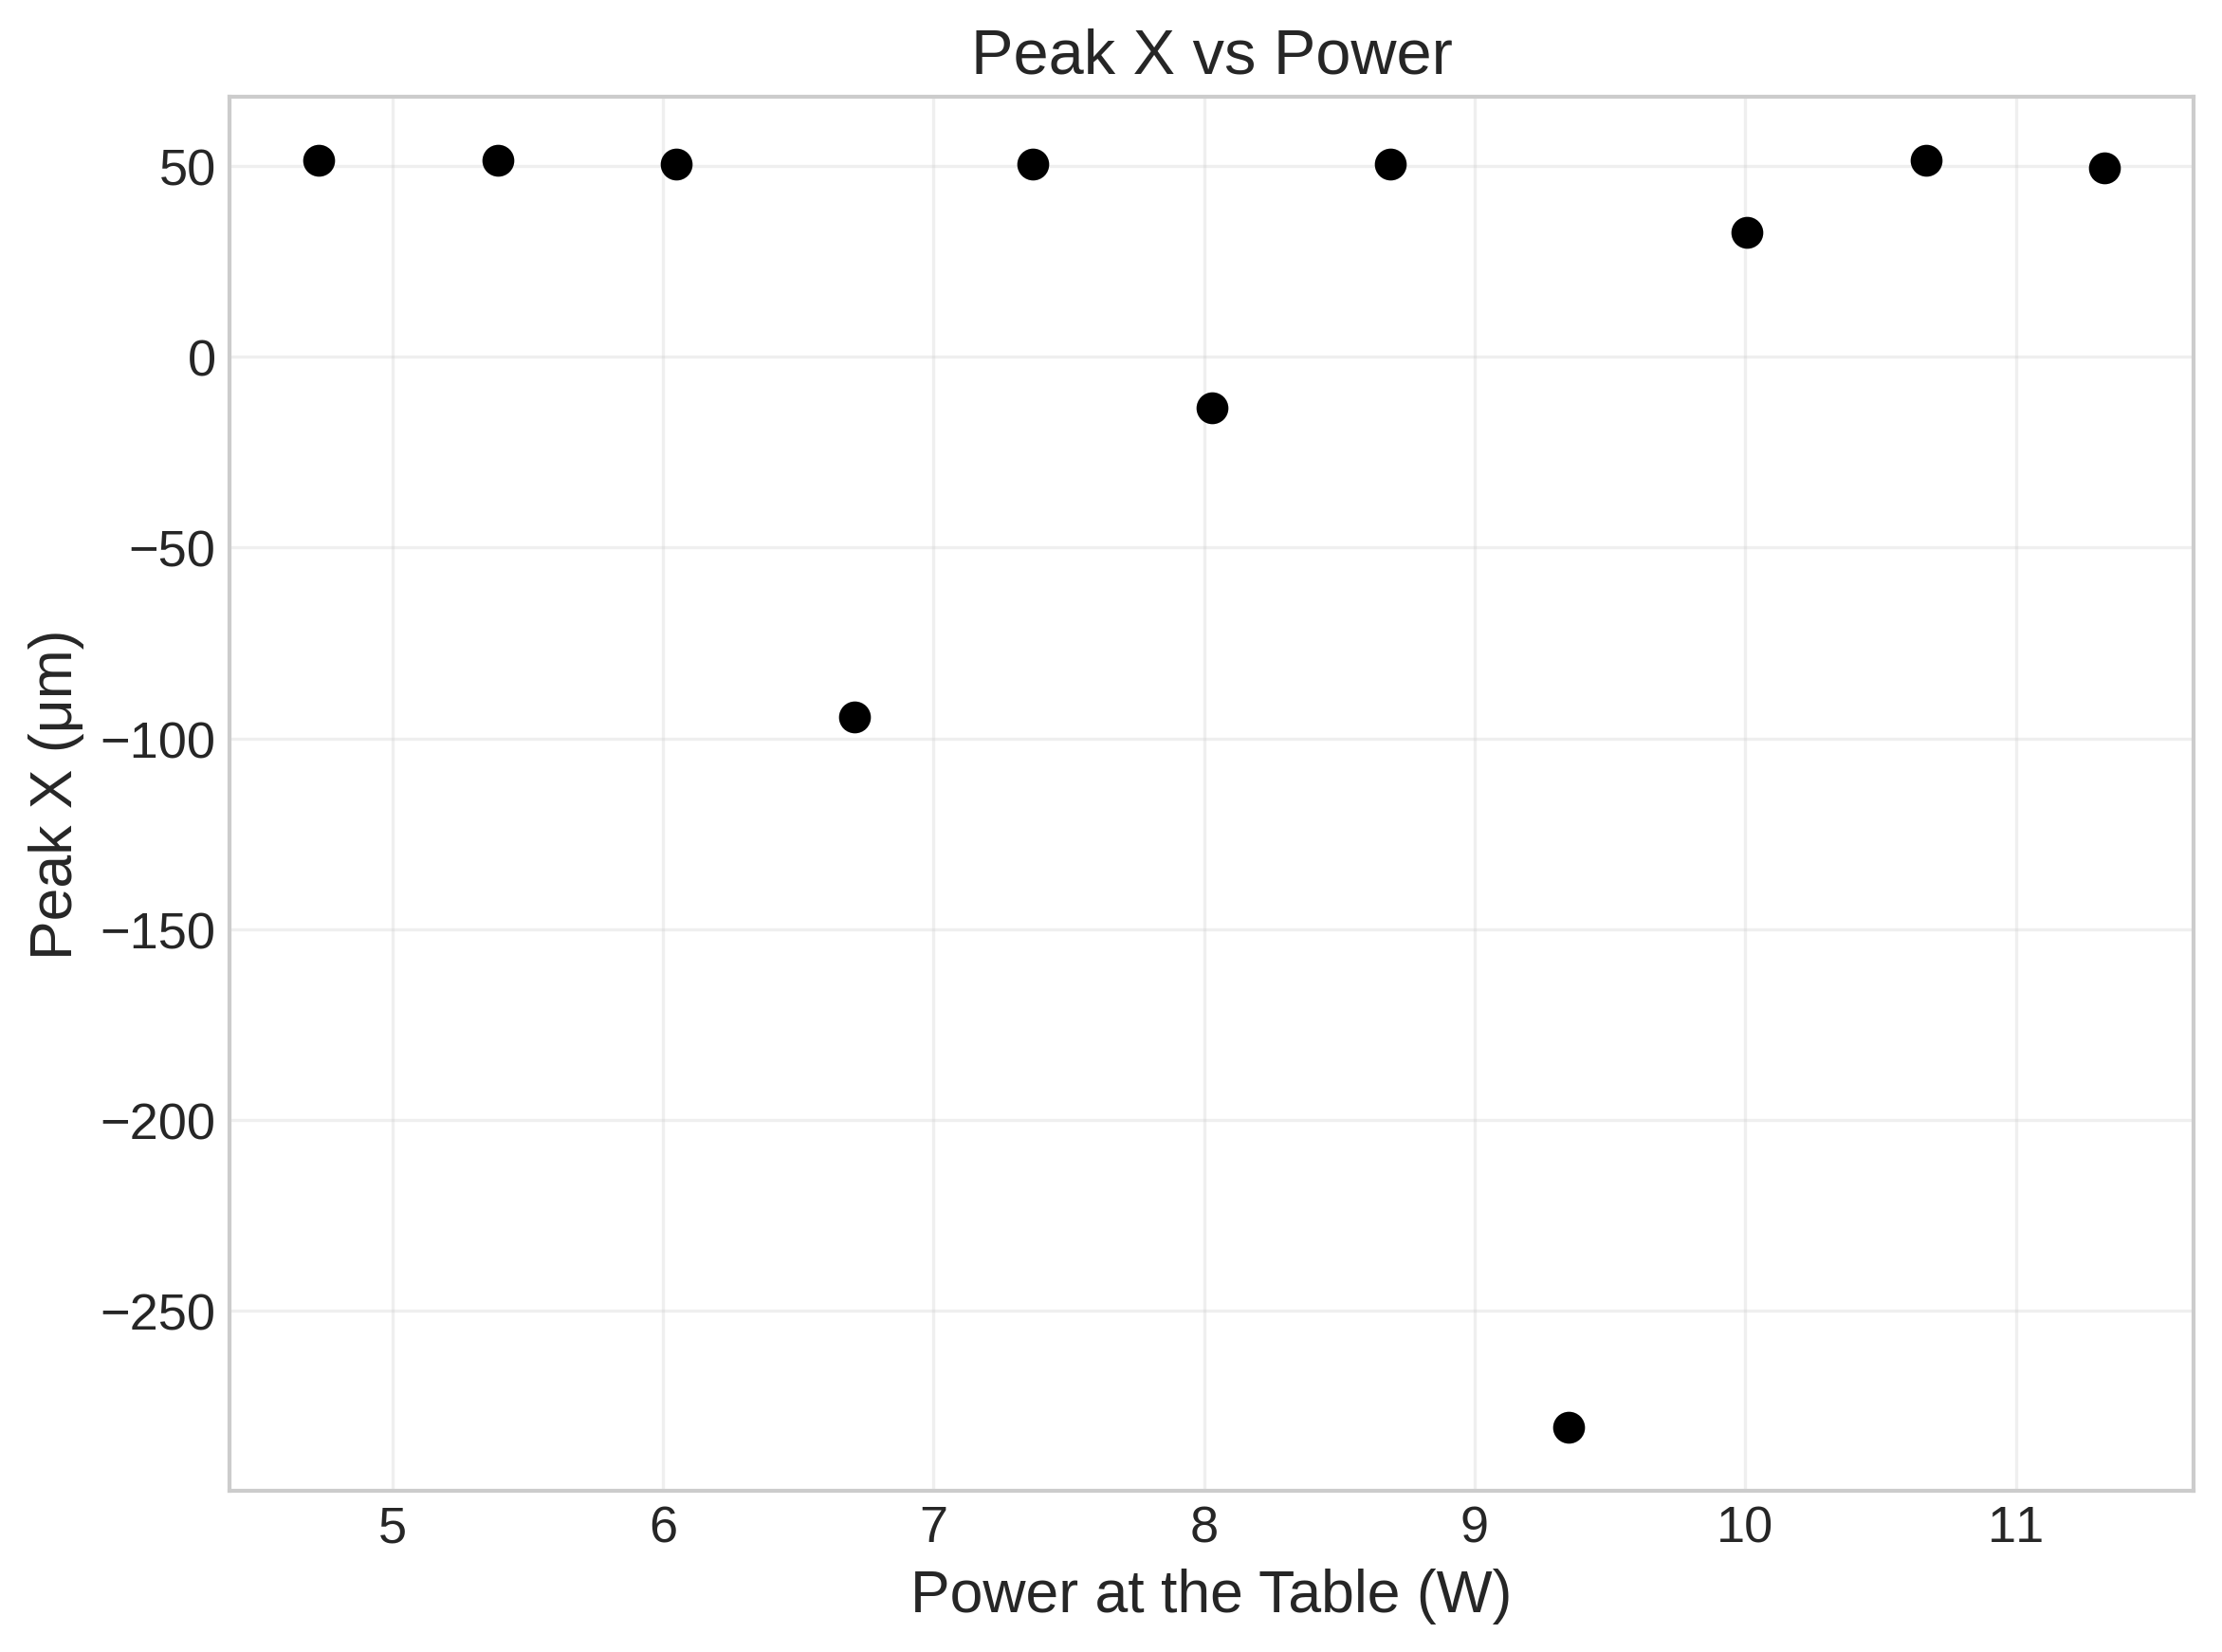

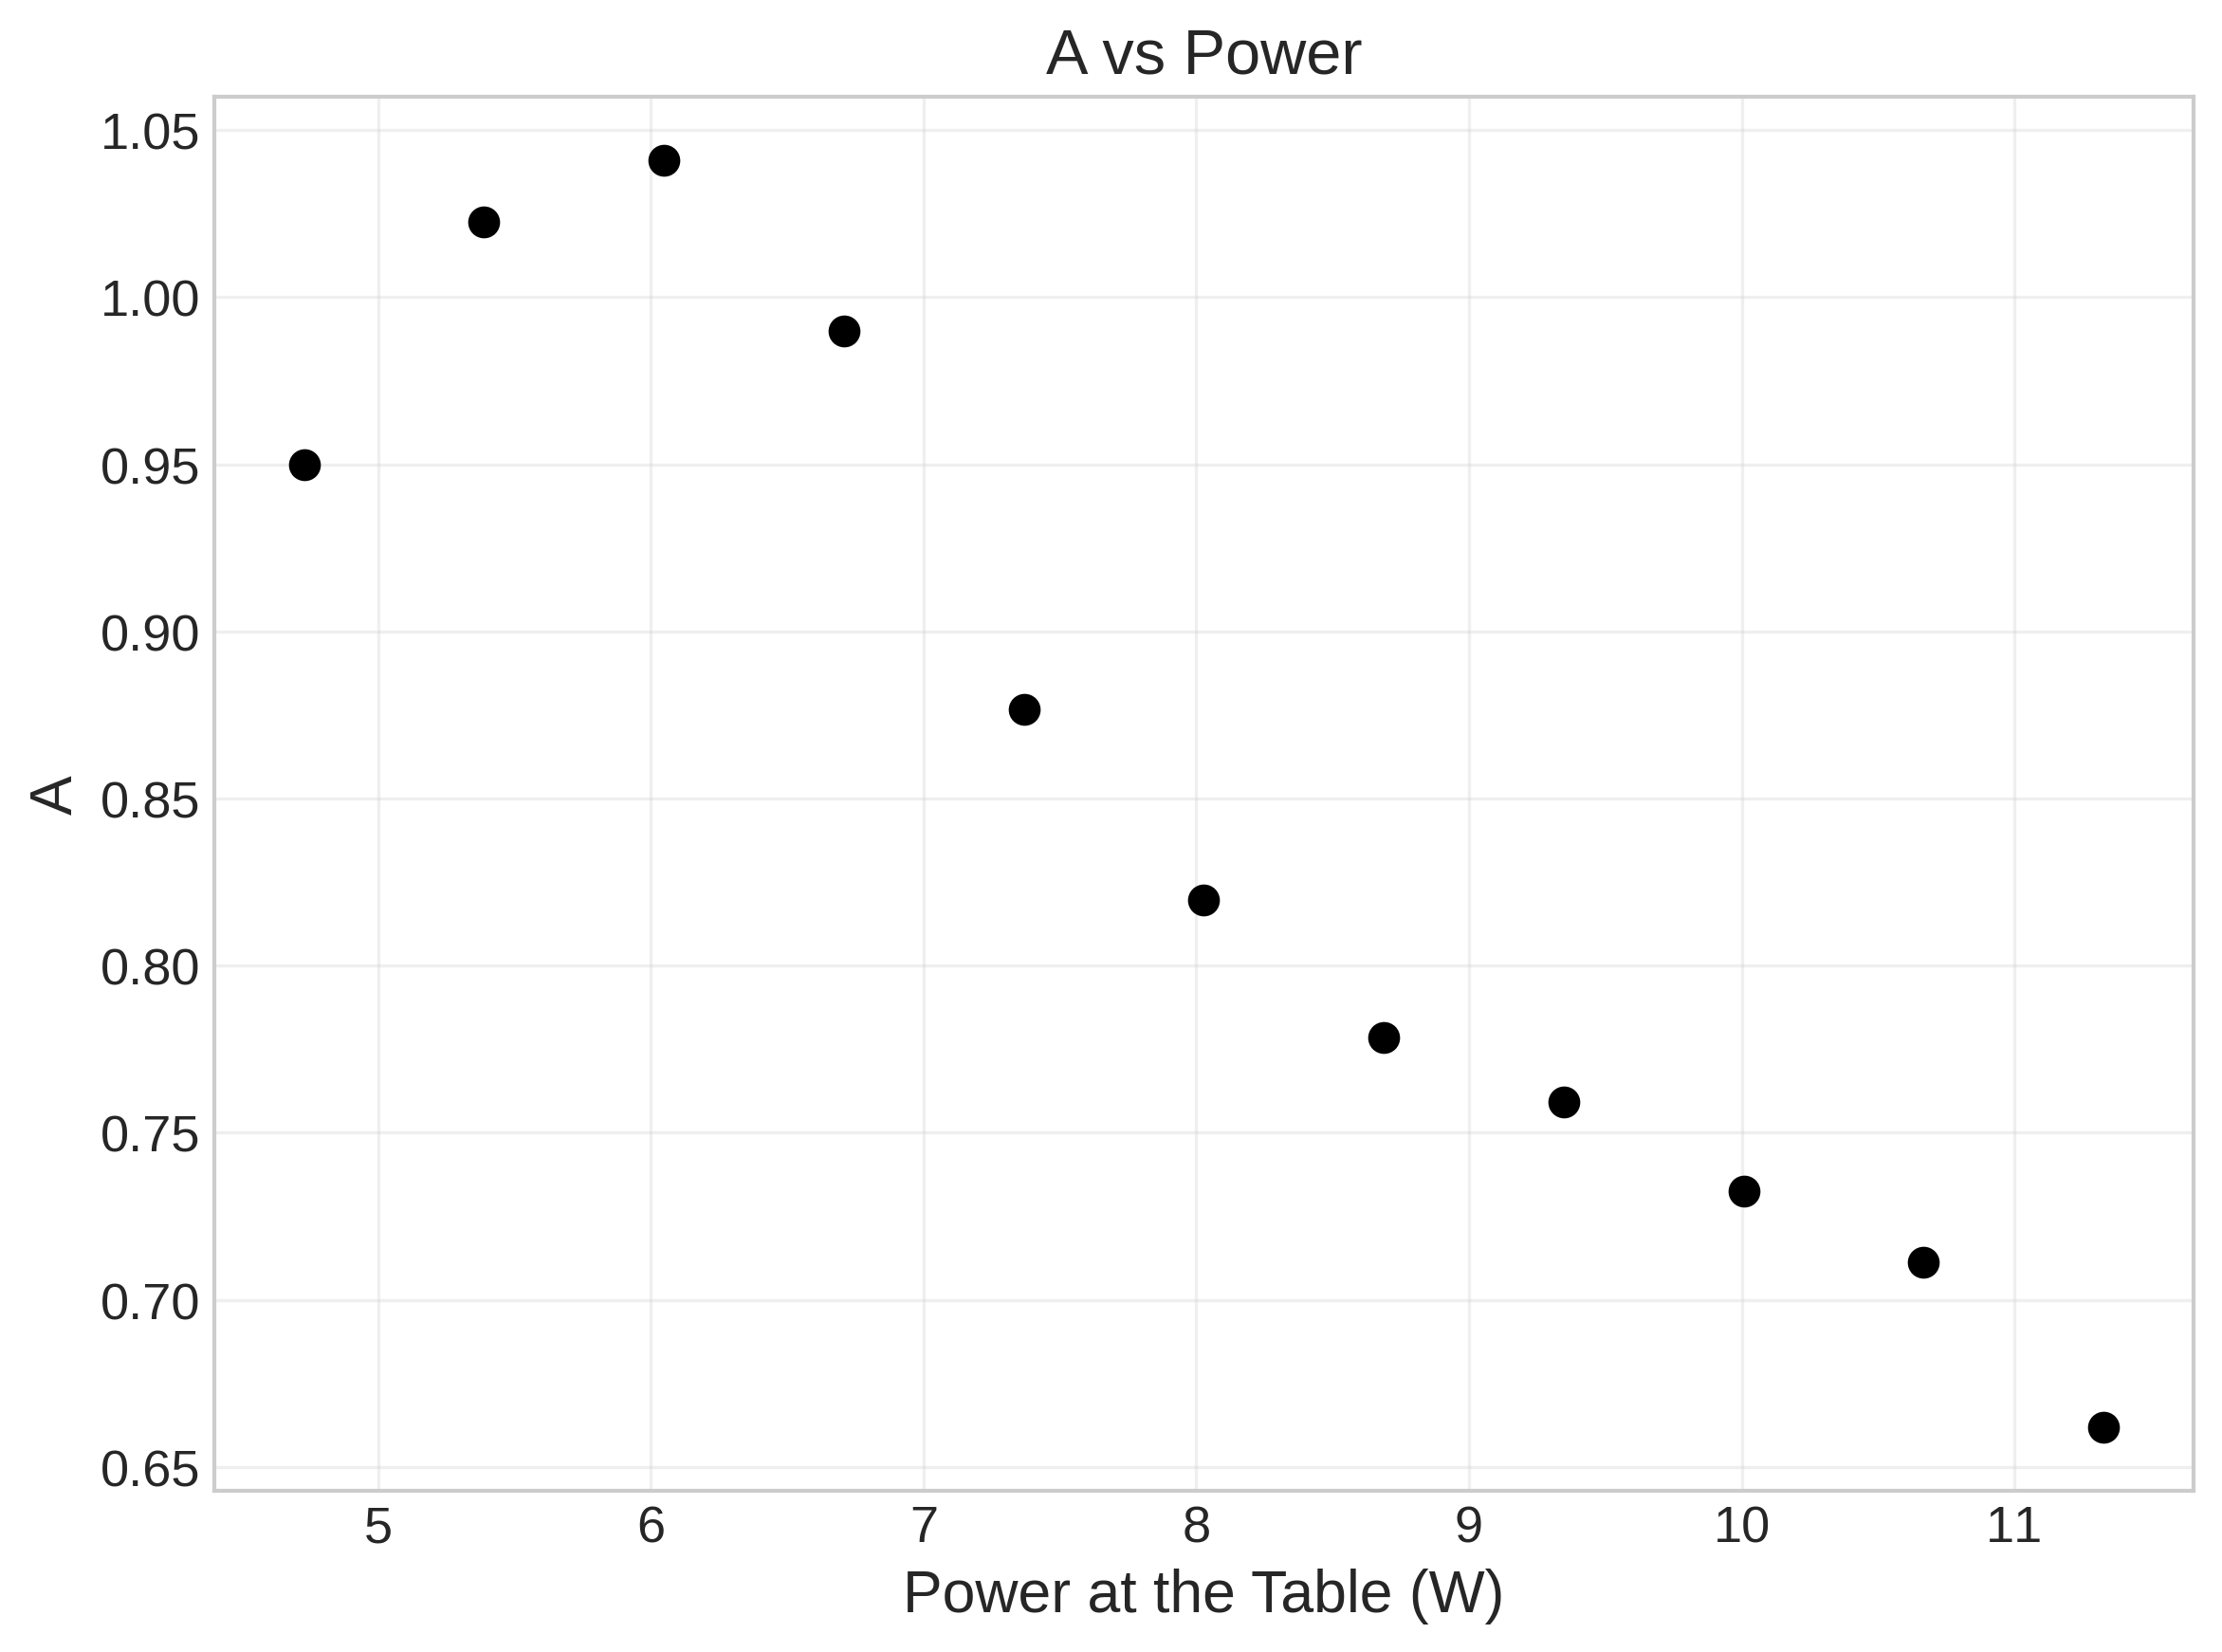

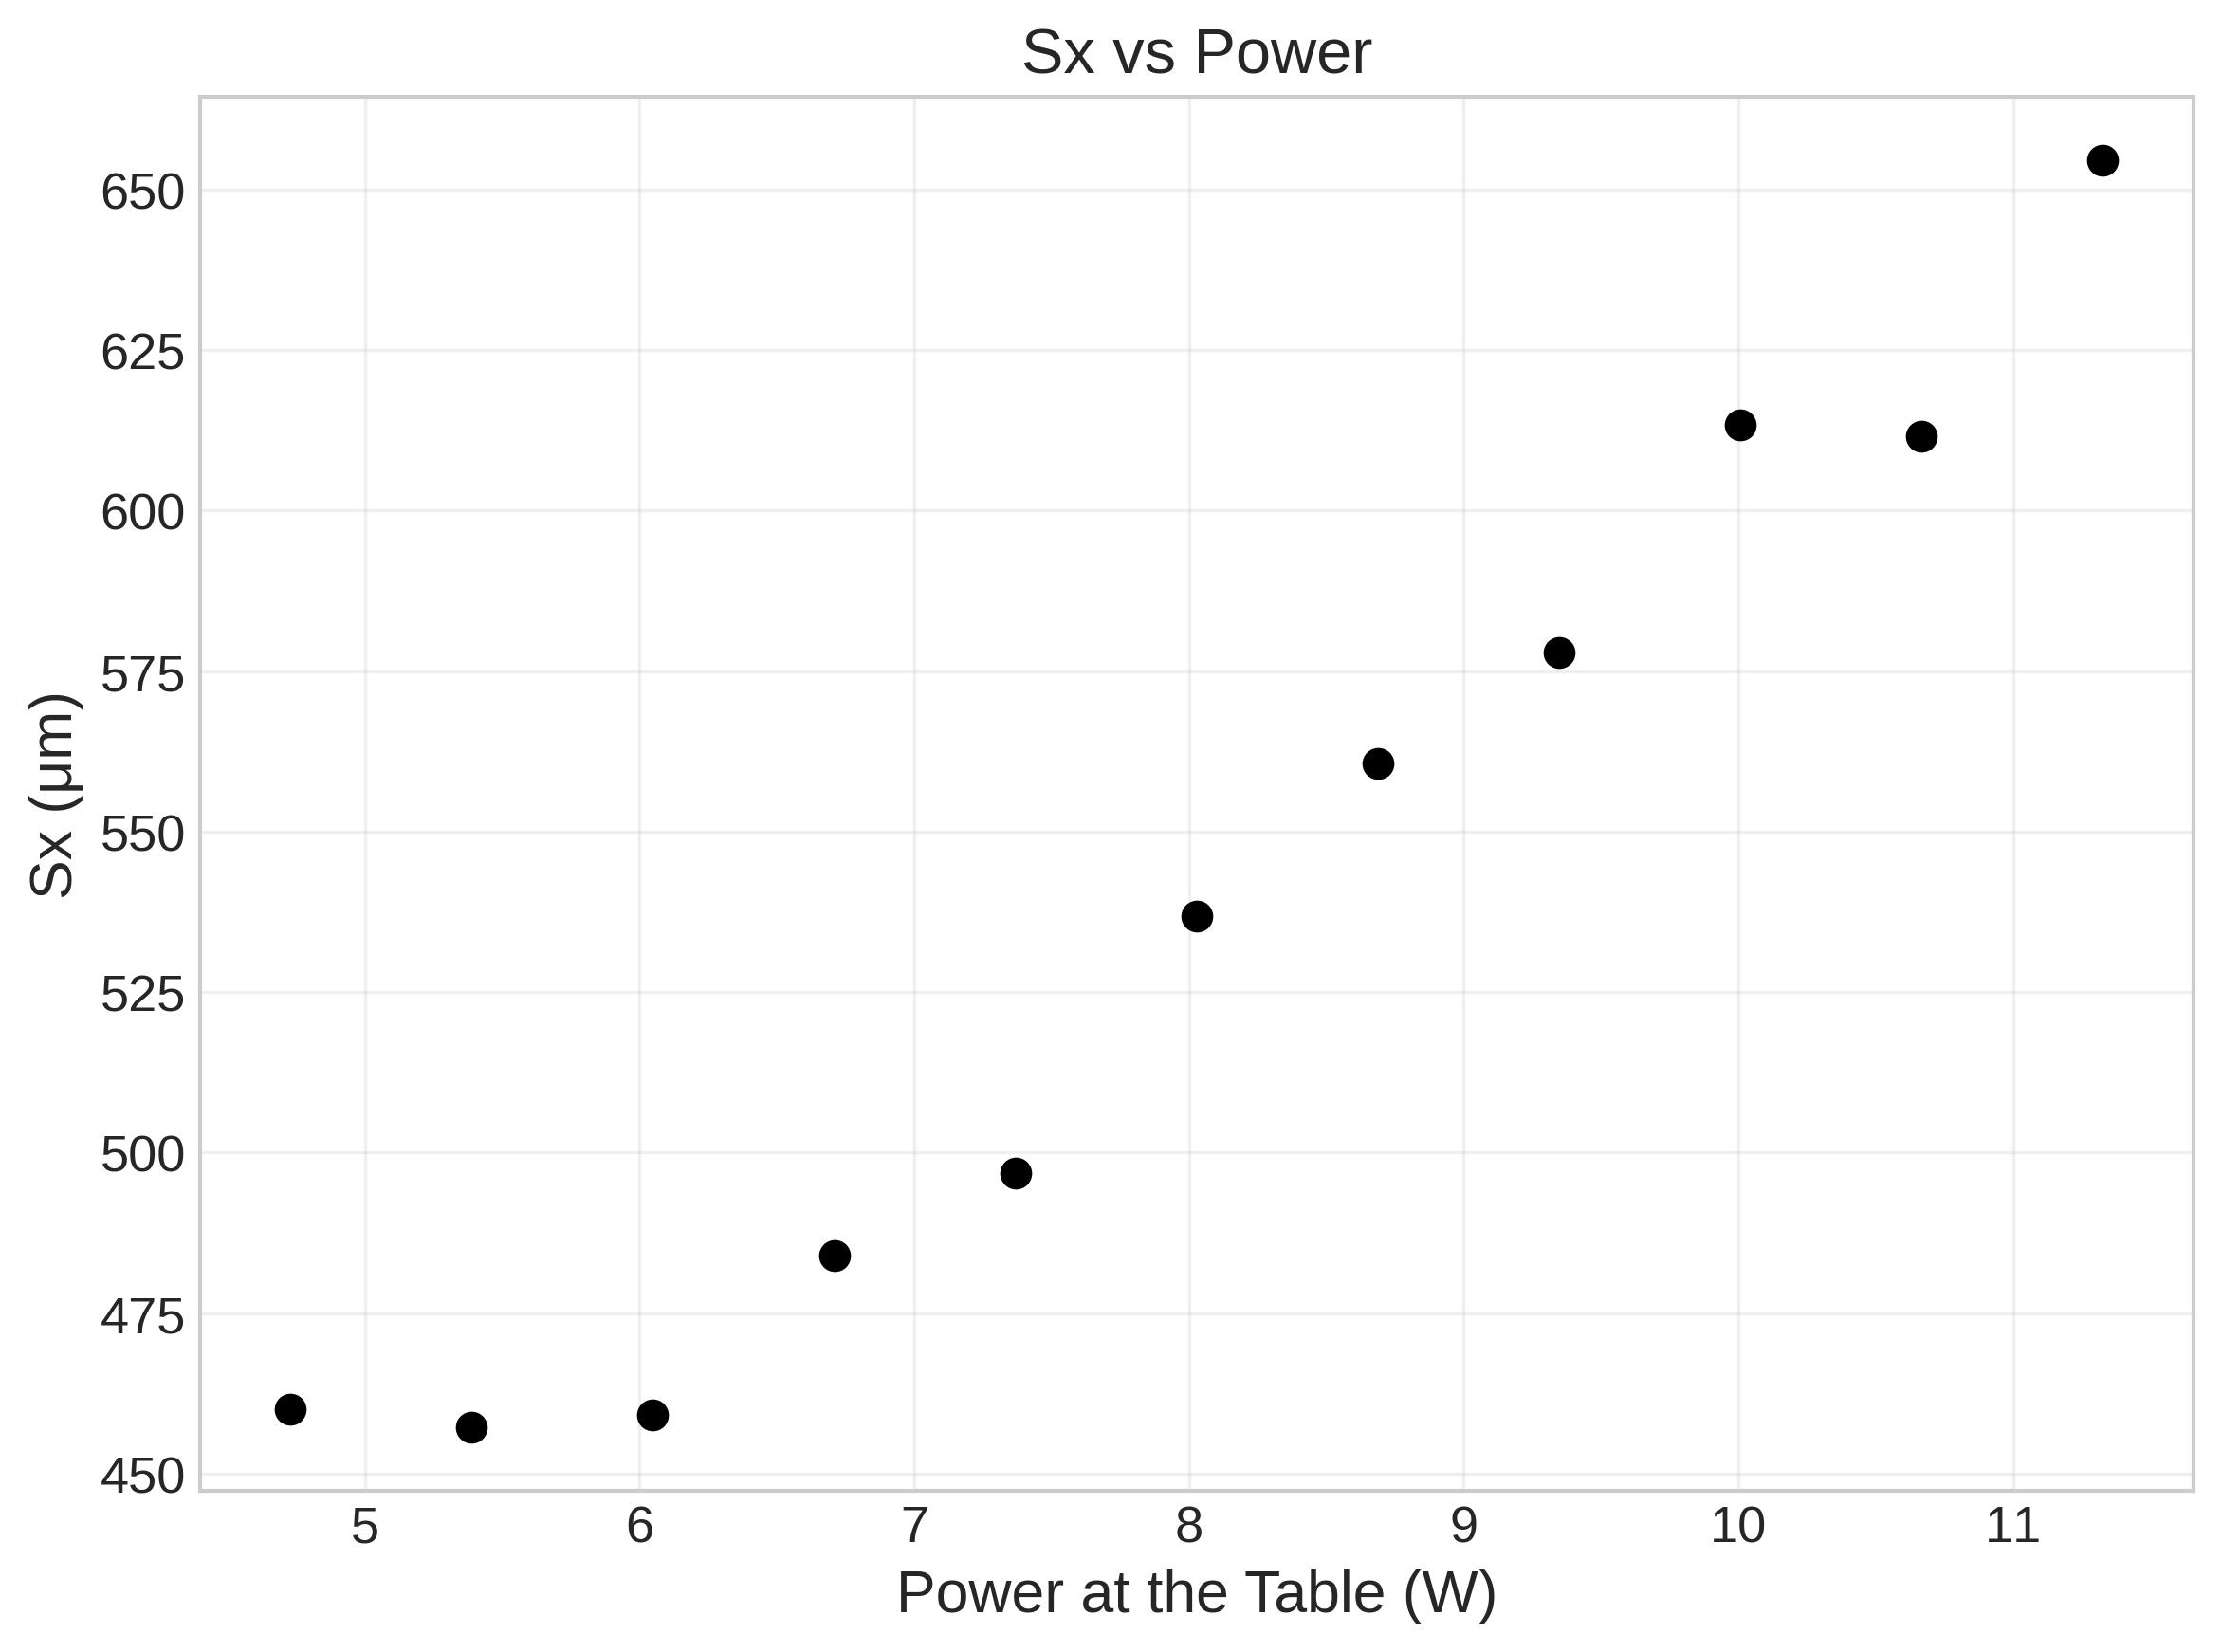

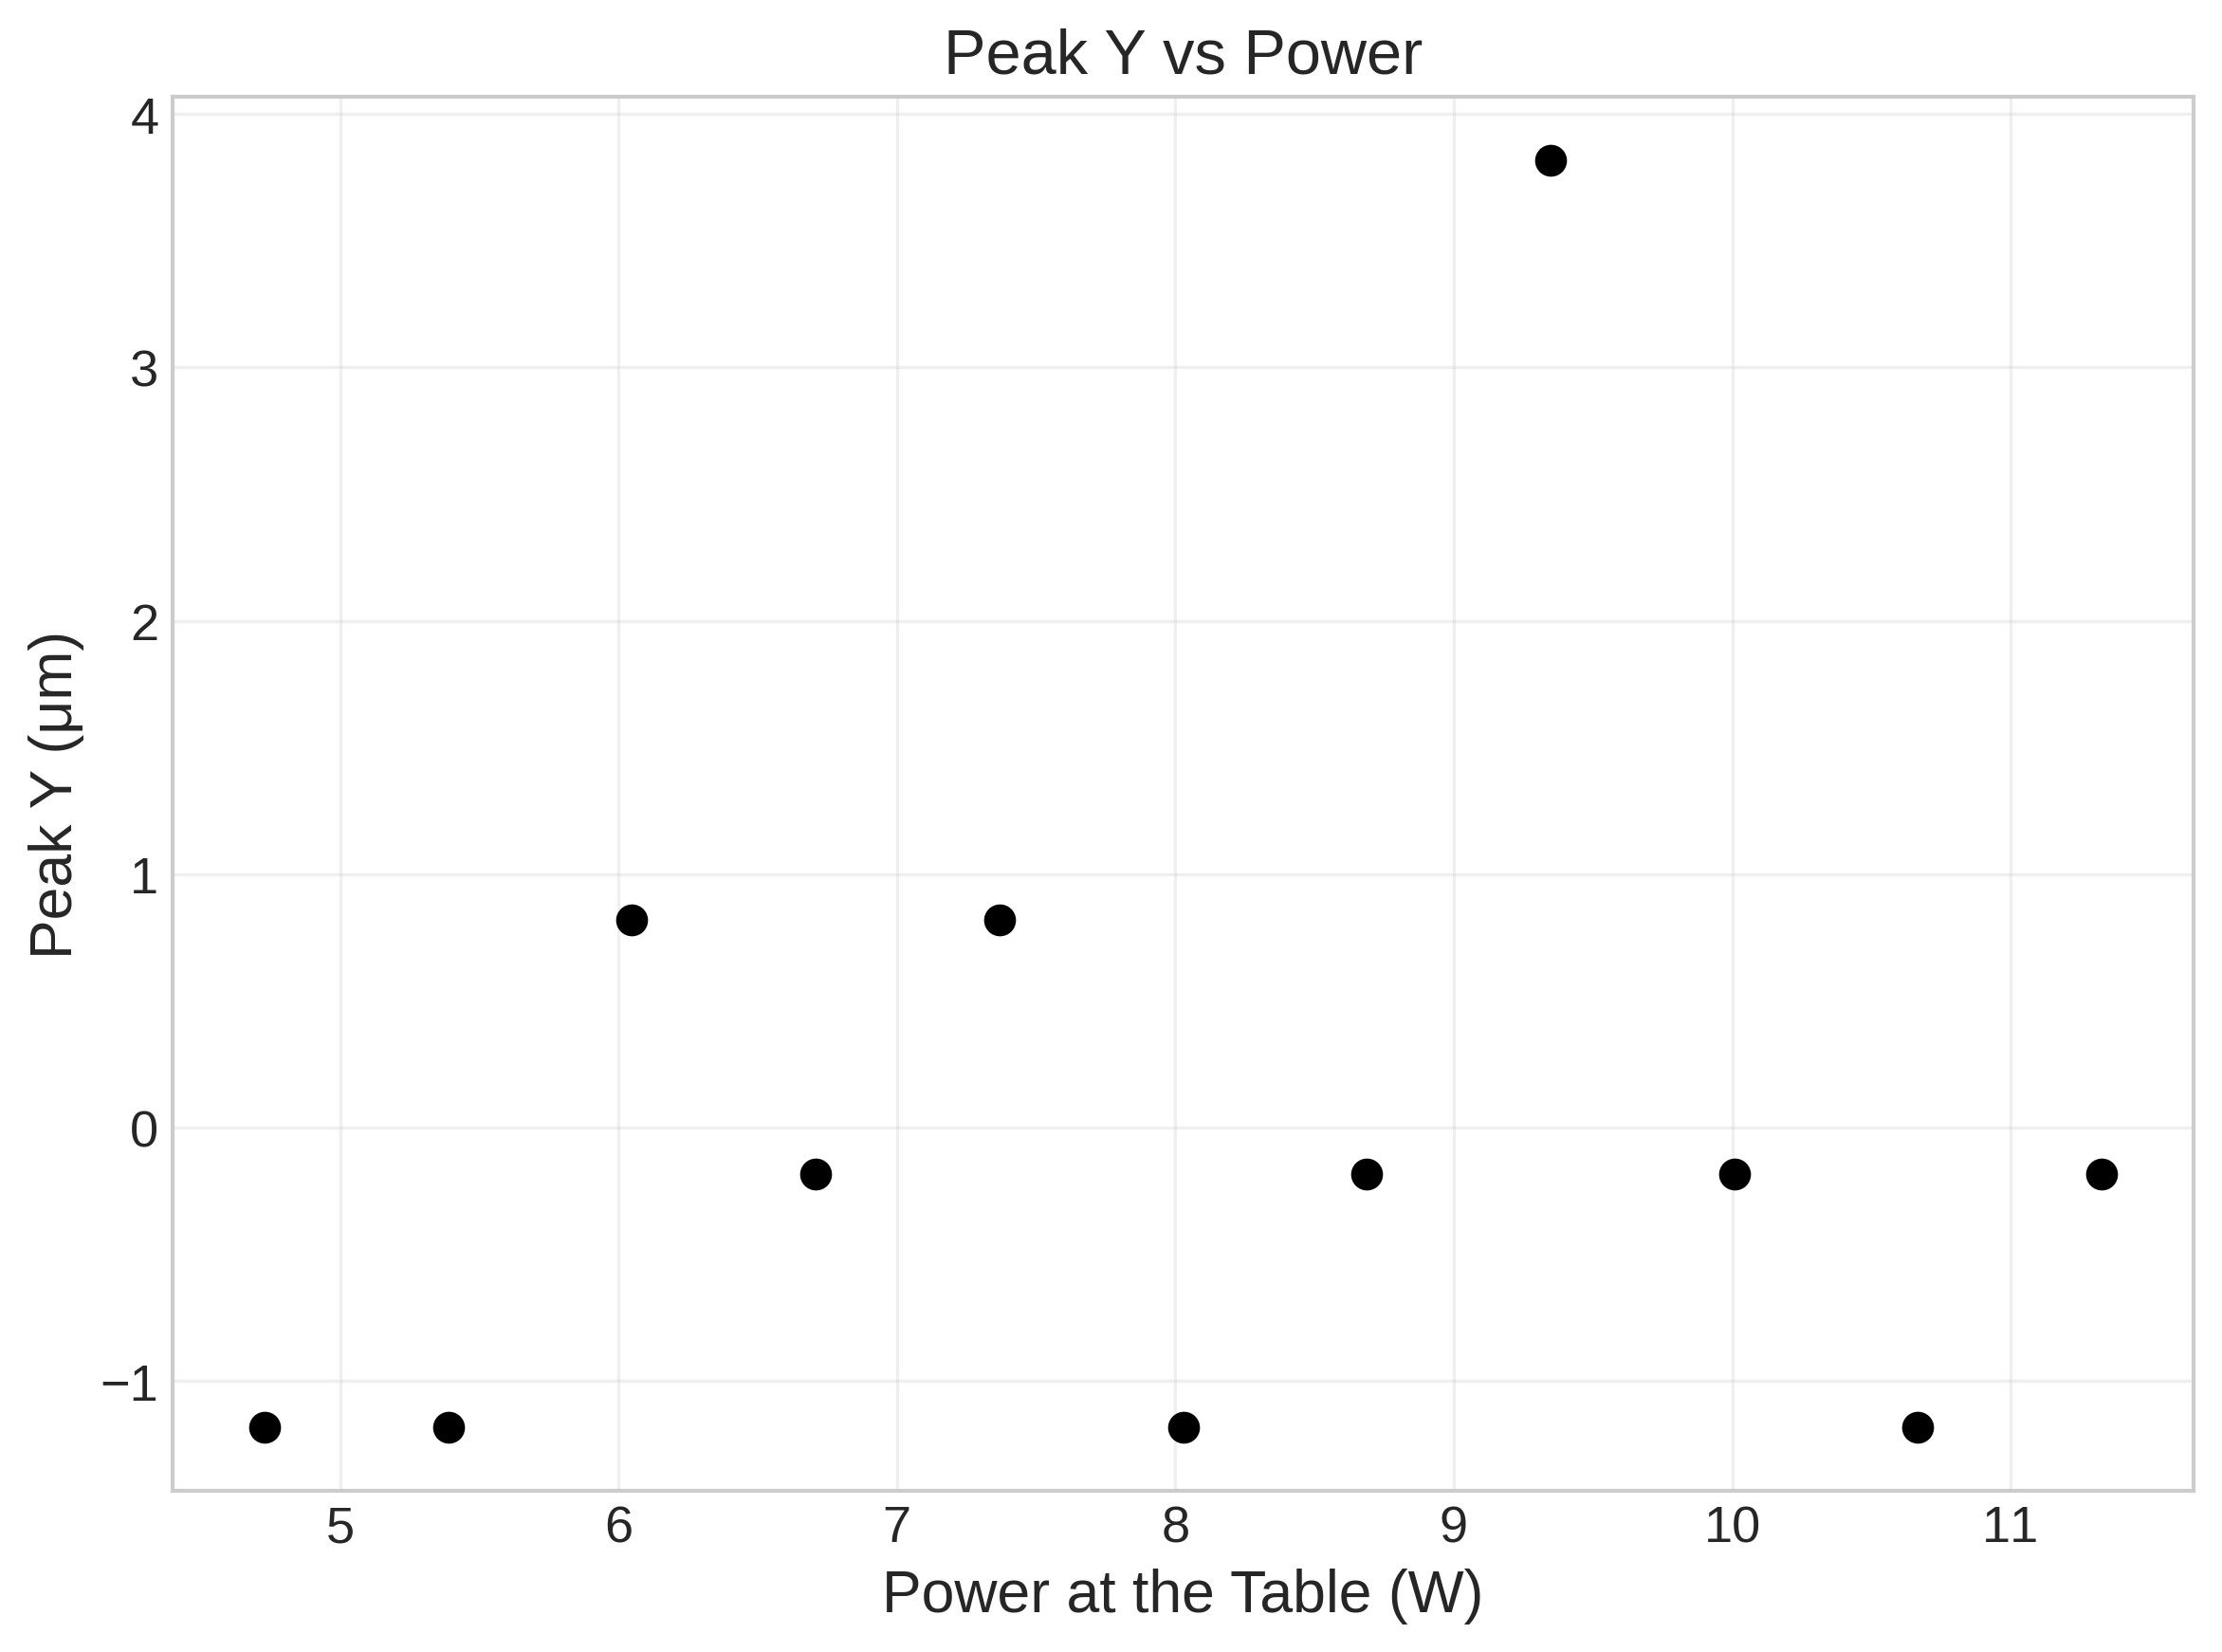

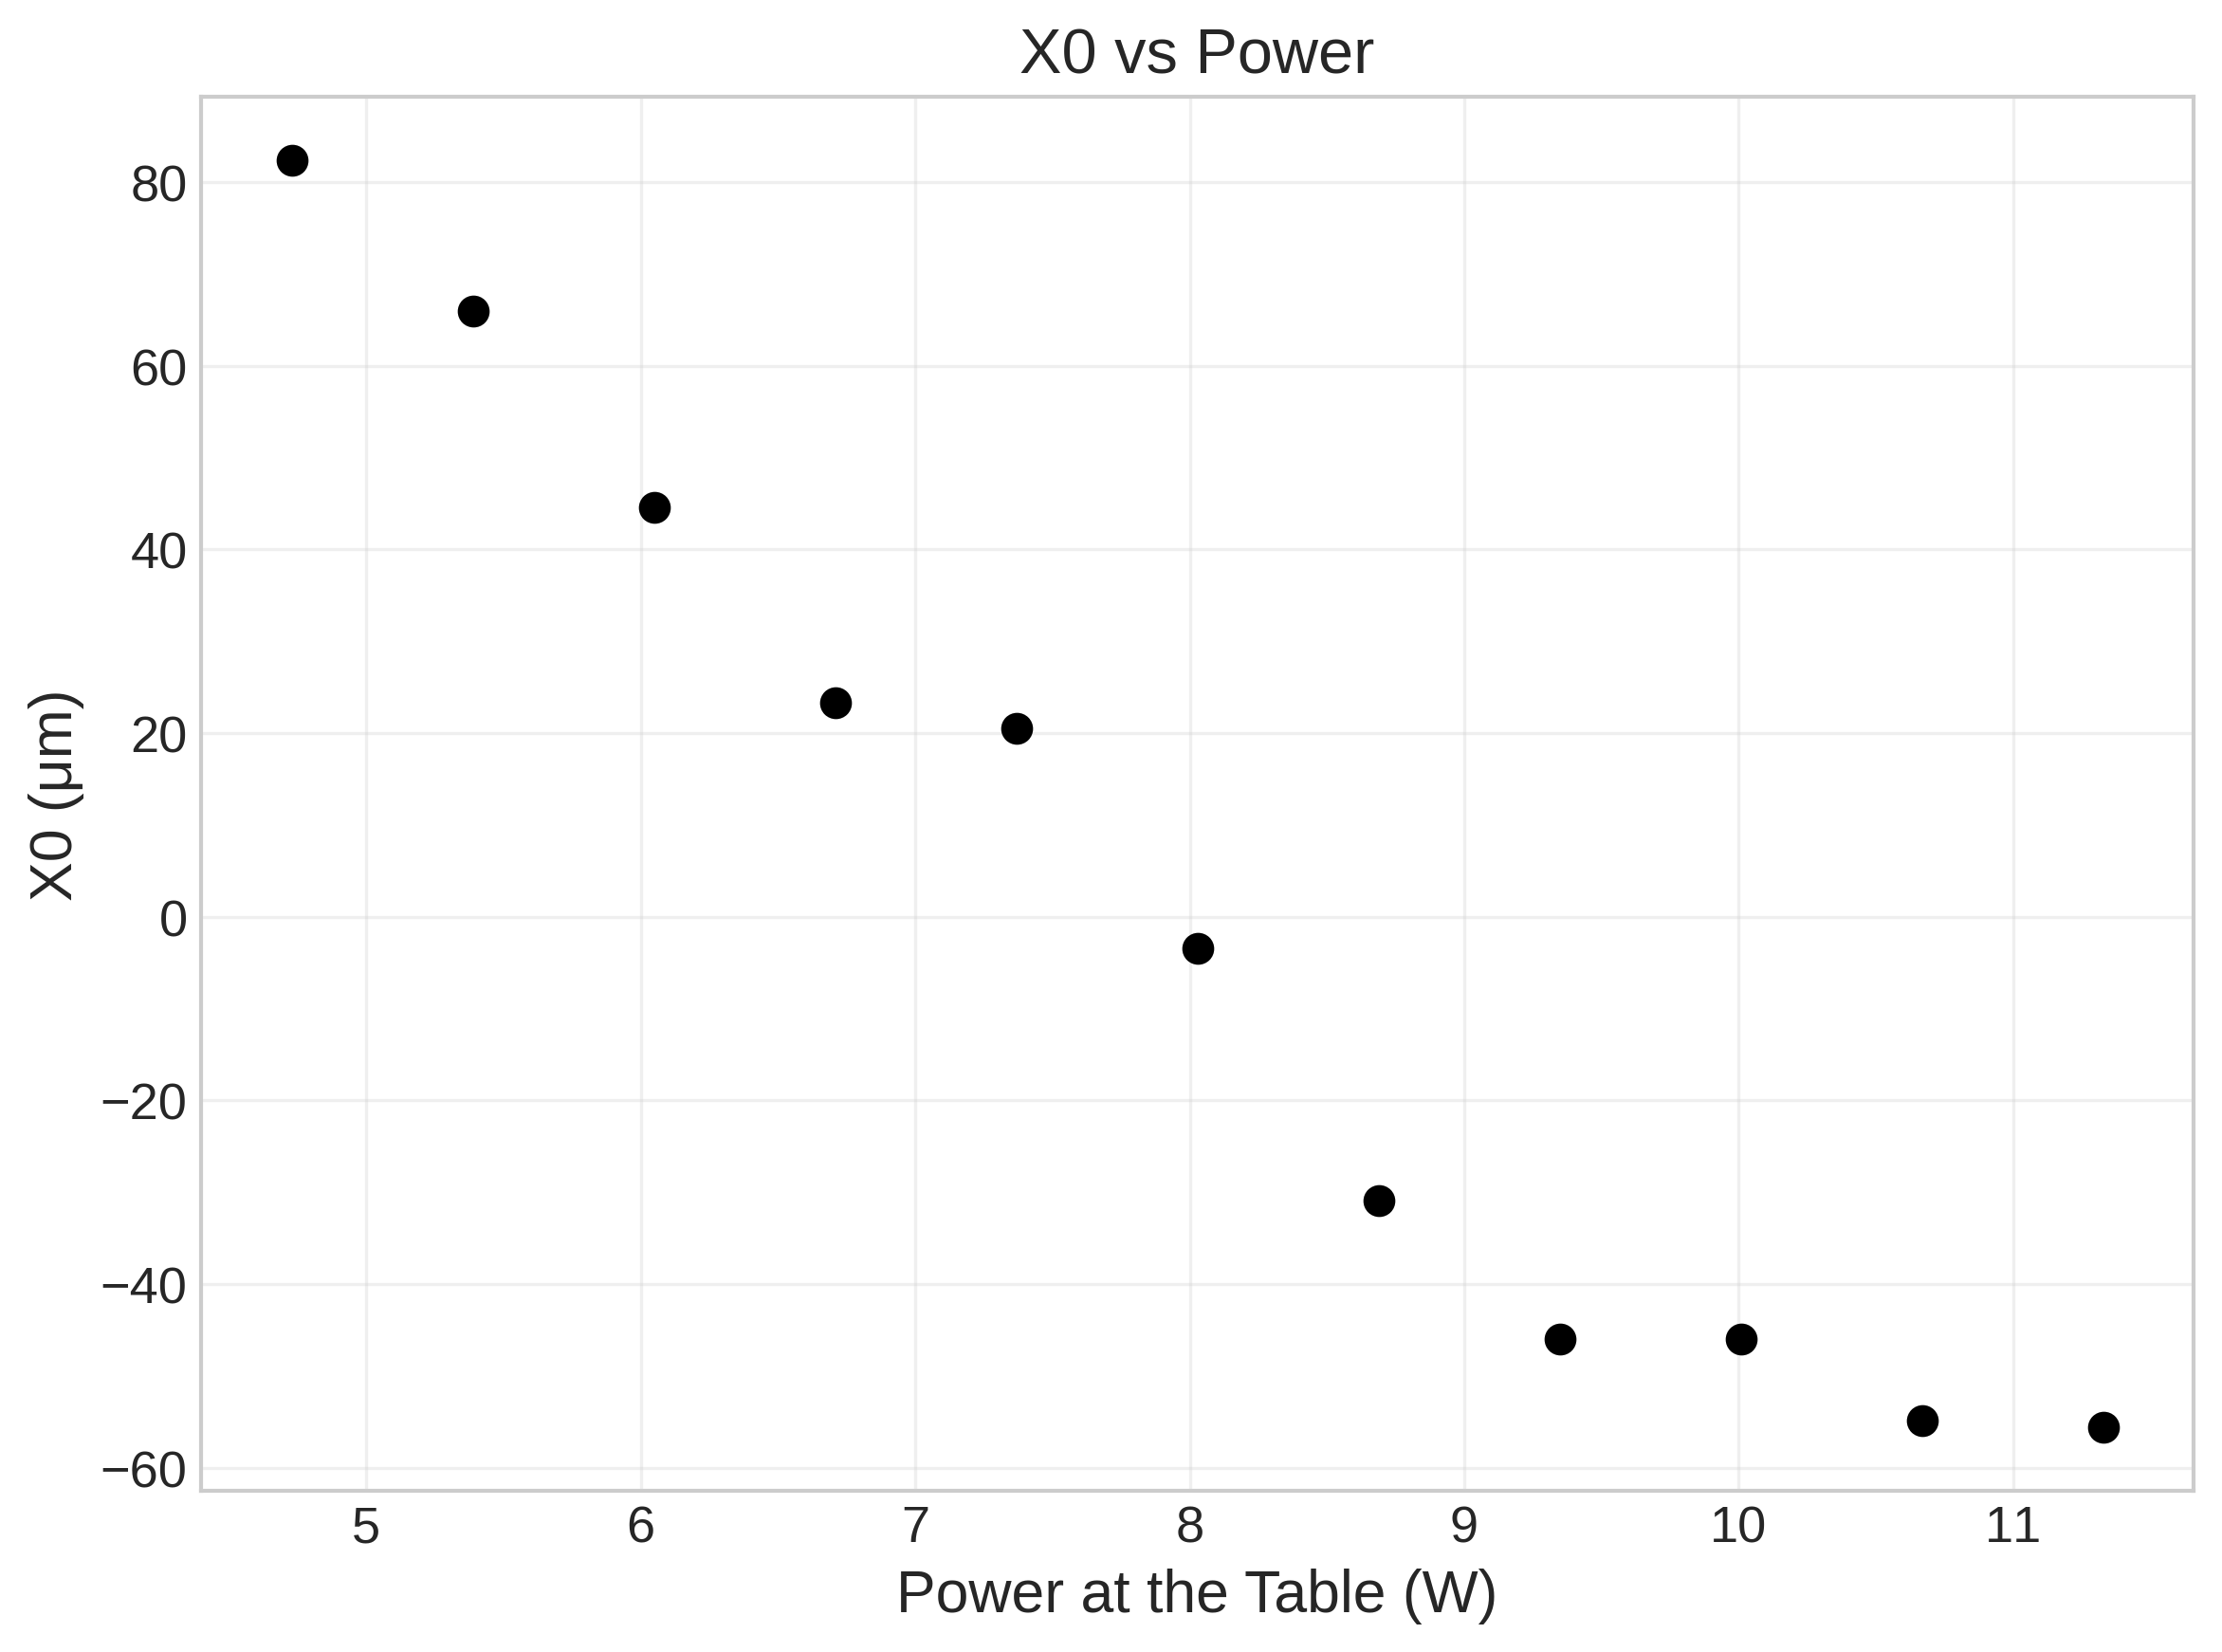

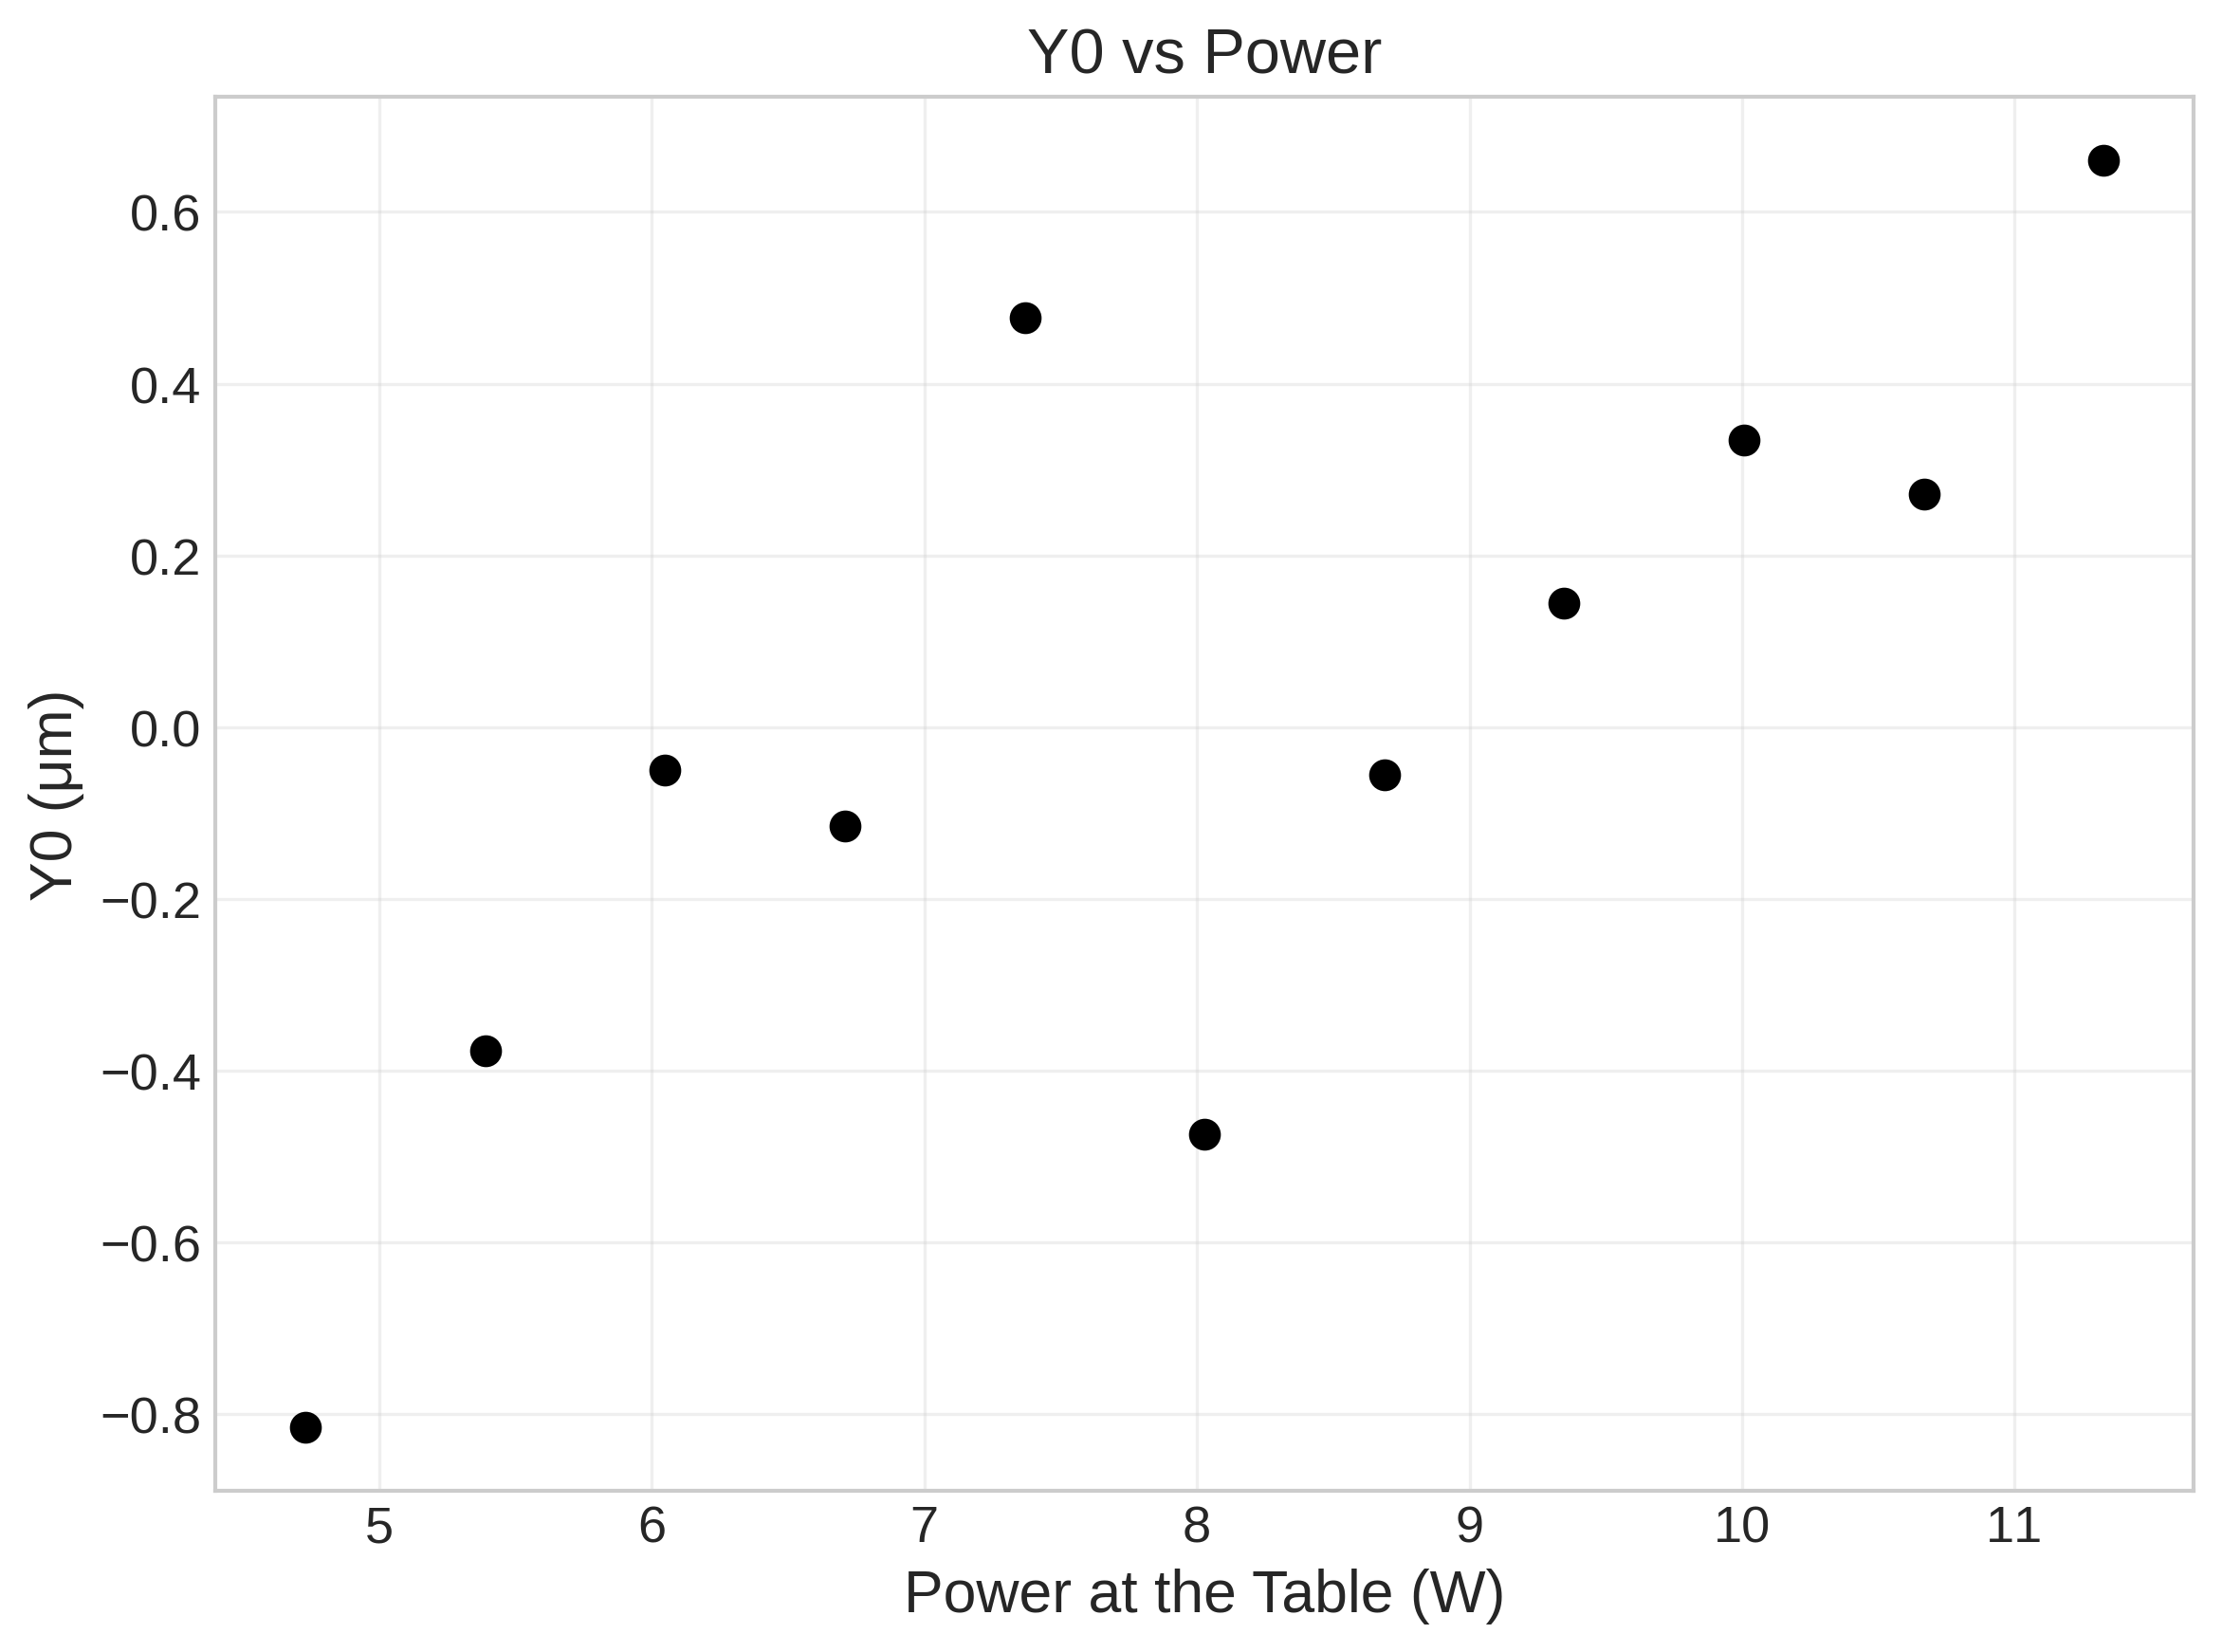

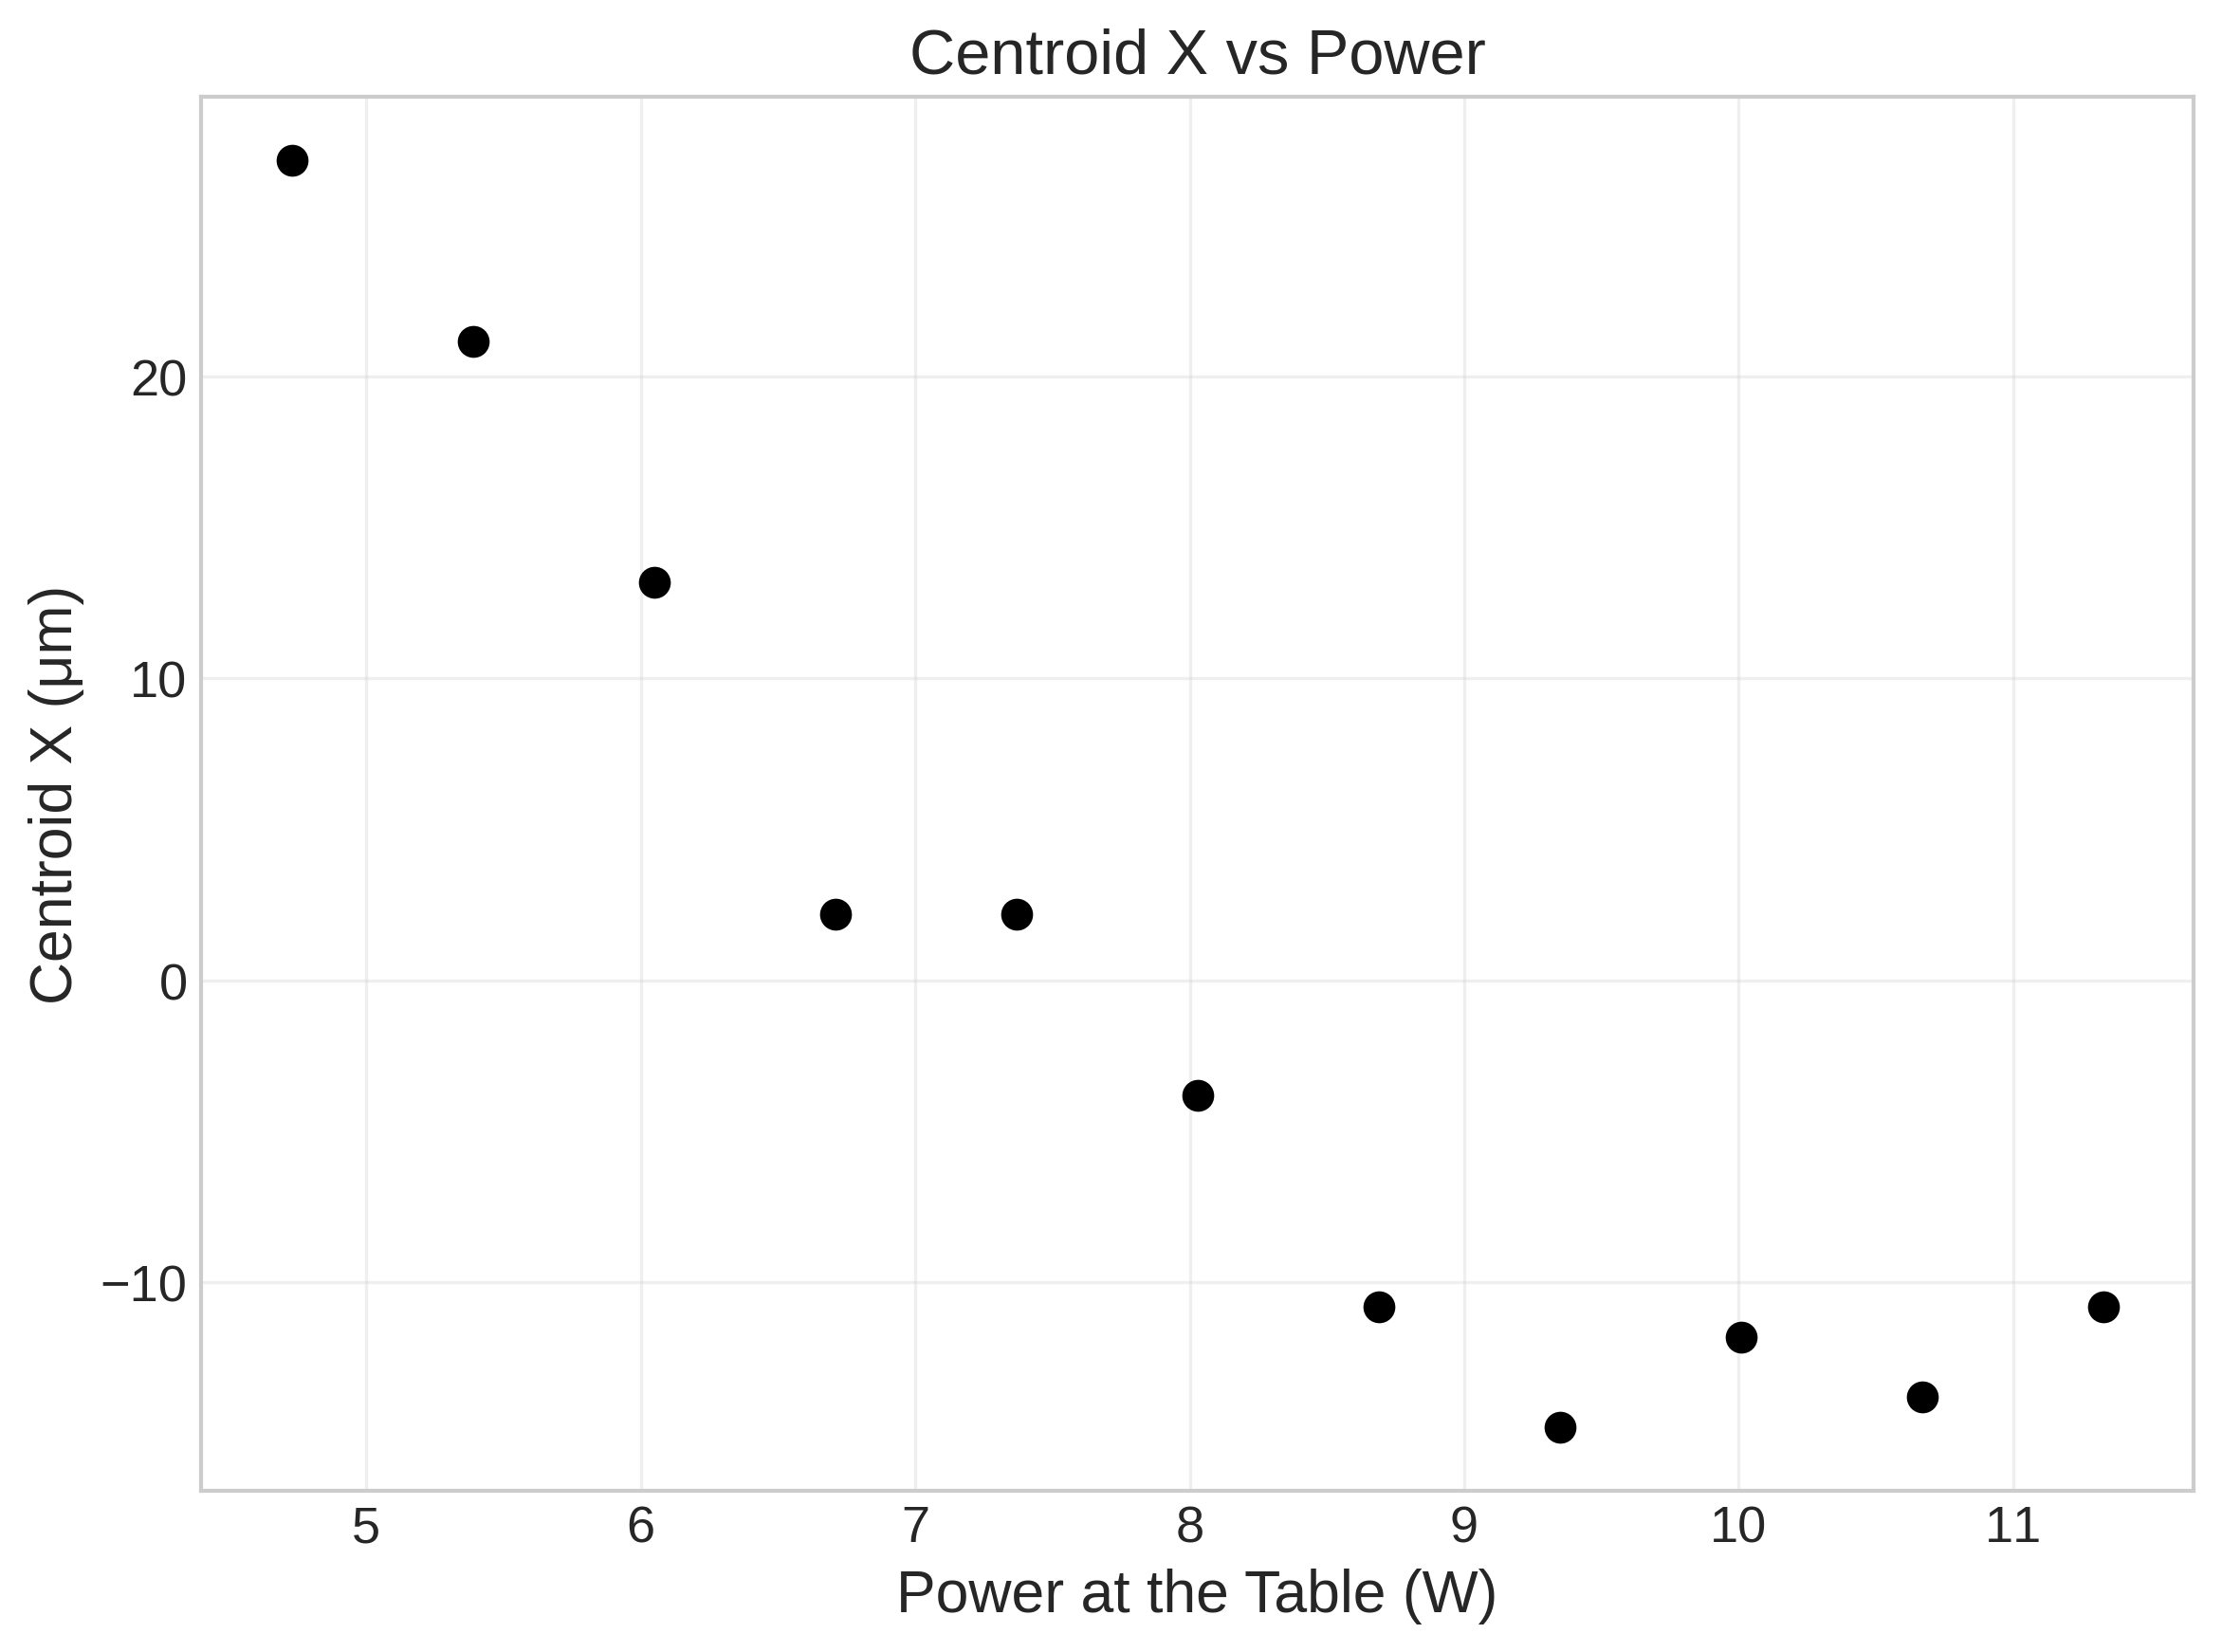

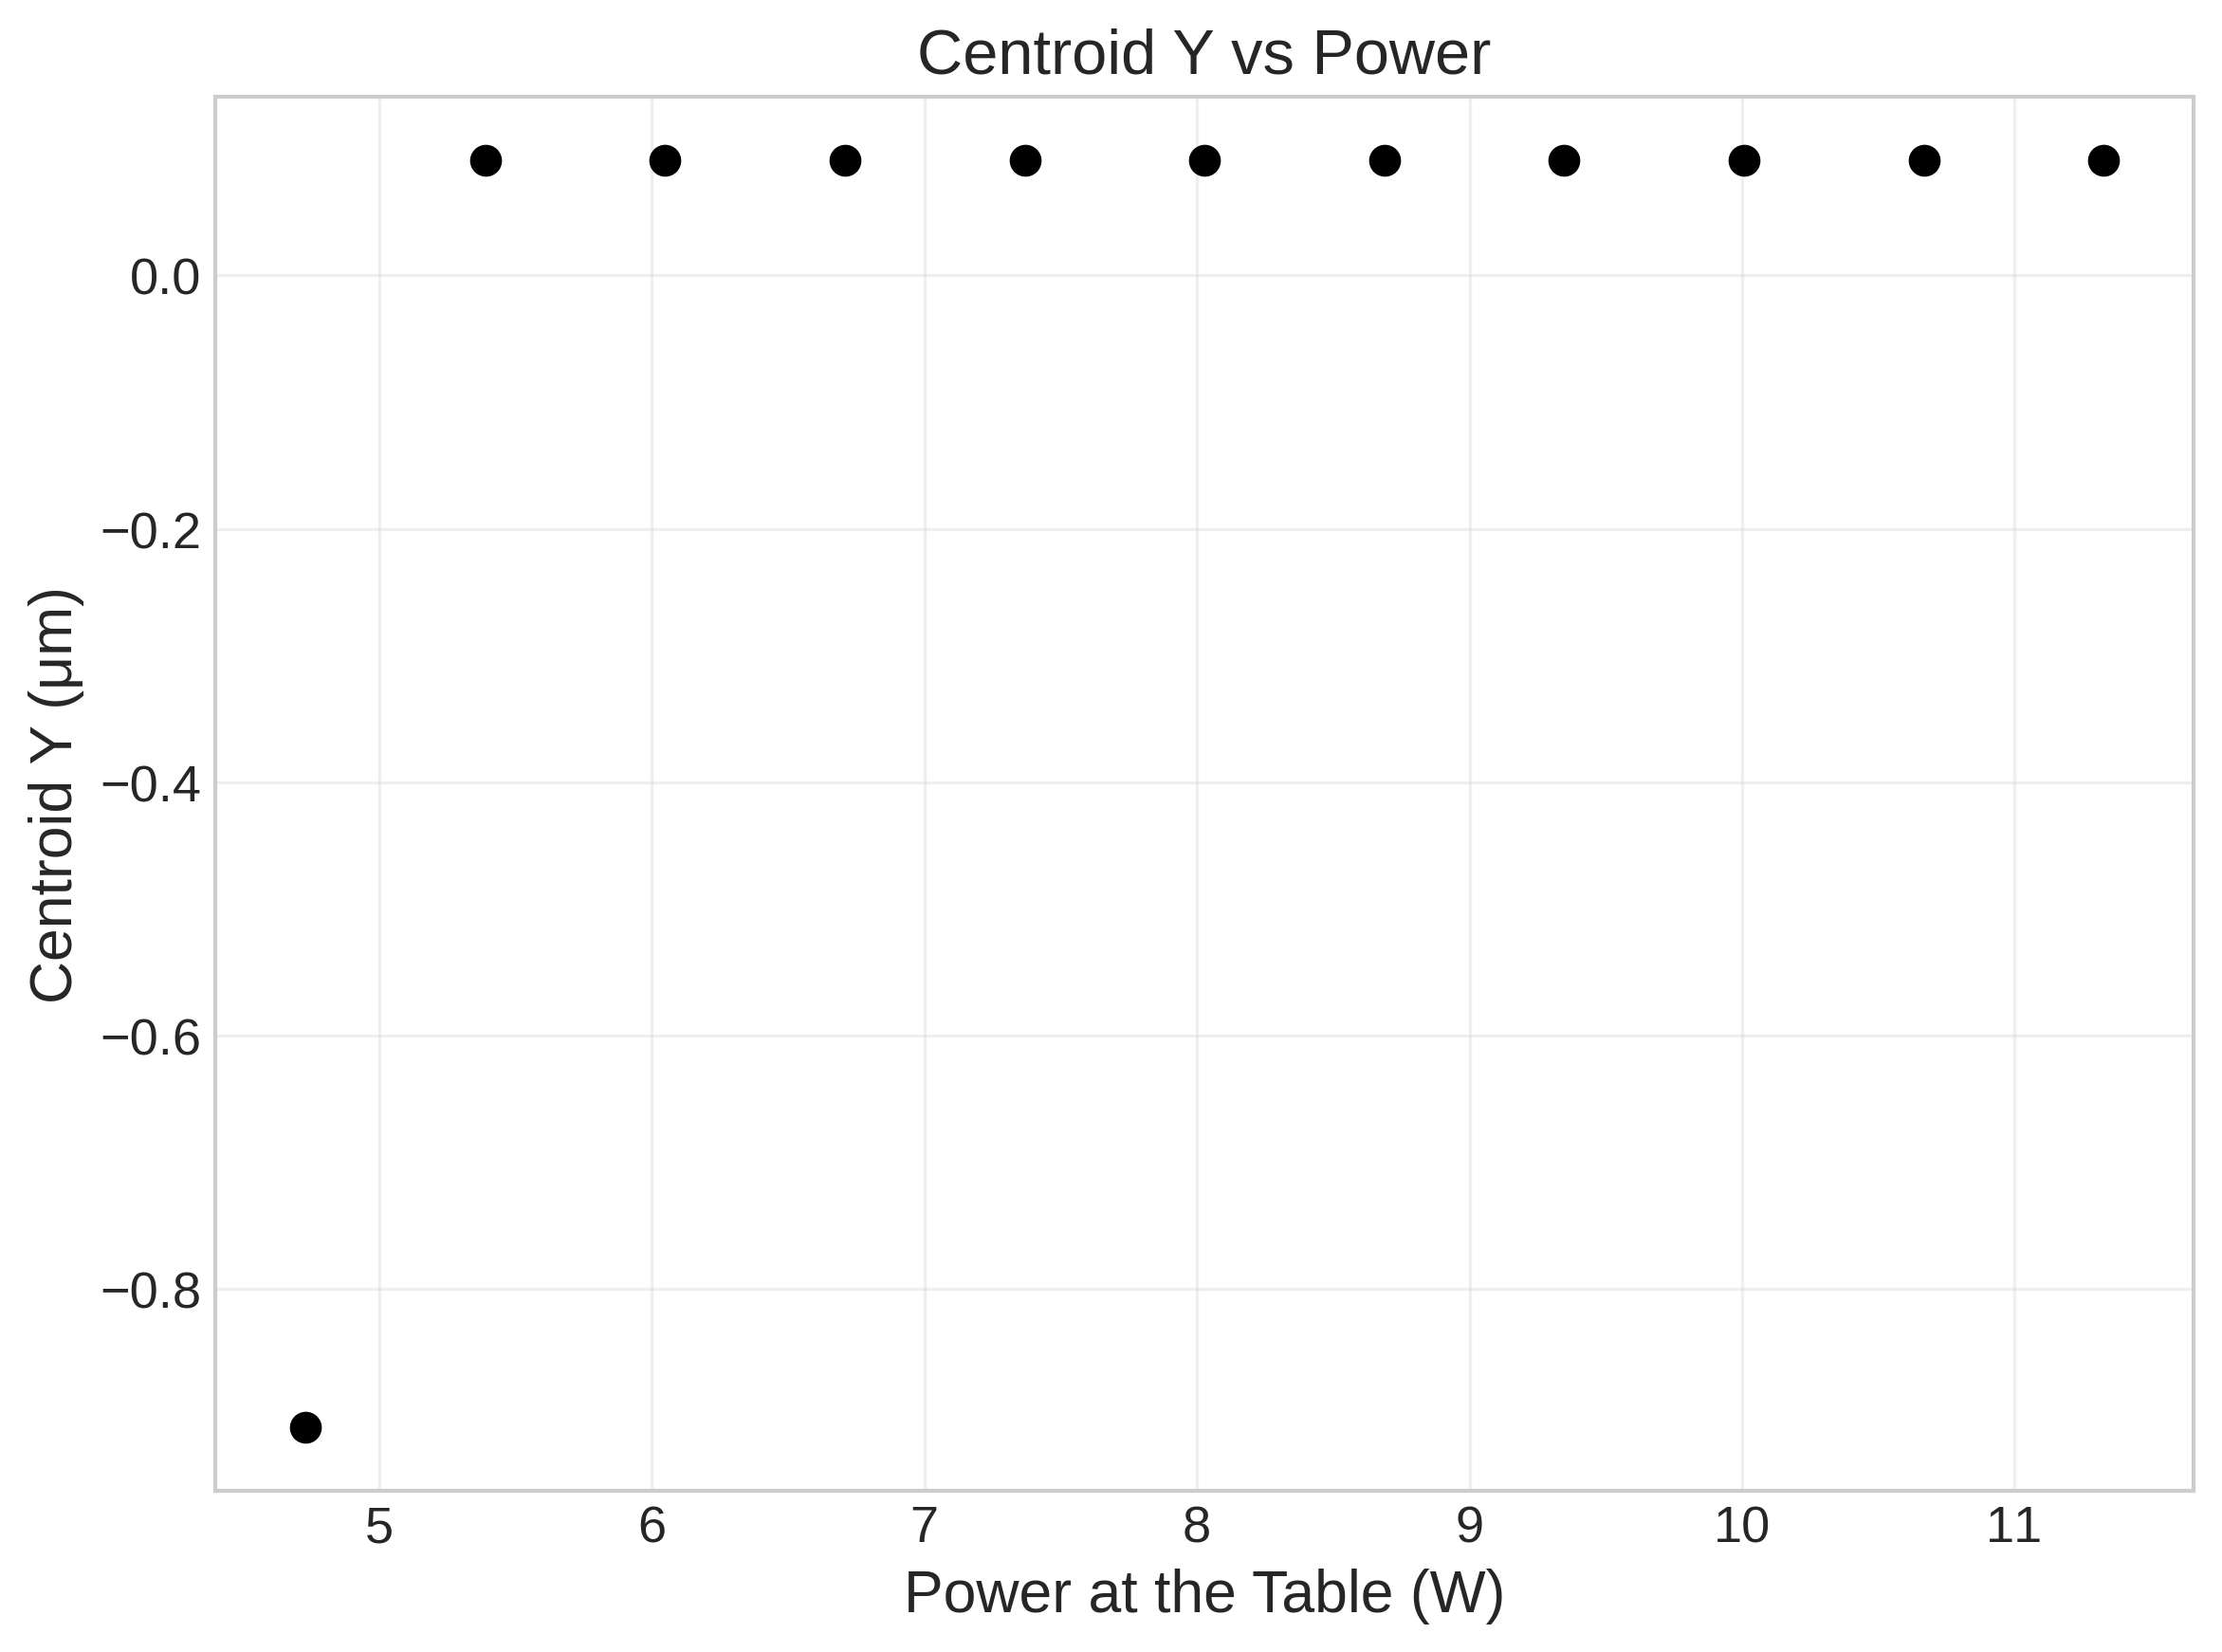

In [ ]:
# exposure time
exposure_time = 0.11e-3  # in seconds
scaling_factor = 1.55 * 1e-6

set = 11  # number of files in the set
range_1 = 0  # starting file number
range_2 = 11  # ending file number


Peak_x_set = []
Peak_y_set = []
Centroid_x_set = []
Centroid_y_set = []
A_set = []
Sx_set = []
Sy_set = []
X0_set = []
Y0_set = []
Wavelength_set = []
Atom_number_set = []
#Scan_params_set = []


# go to all the files in the set see if scan parameters are same or not
# if same then extract the data and store in the lists
# if not same then print the message and stop the program

for i in range(range_1, range_2):
        Extractor_file_instance = Extractor_file(i)
        dataset = Extractor_file_instance.data
        Peak_x_set.append(dataset["peakx"])
        # Etract data and store in lists
        Peak_y_set.append(dataset["peaky"])
        Centroid_x_set.append(dataset["centroidx"])
        Centroid_y_set.append(dataset["centroidy"])
        A_set.append(dataset["A"])
        Sx_set.append(dataset["sx"])
        Sy_set.append(dataset["sy"])
        X0_set.append(dataset["x0"])
        Y0_set.append(dataset["y0"])
        Wavelength_set.append(dataset["wavelength"])
        Atom_number_set.append(dataset["atom_number"])
        #Scan_params_set.append(dataset["scan_params"])


# Convert lists to numpy arrays for easier manipulation
Peak_x_set = np.asarray(Peak_x_set)
Peak_y_set = np.asarray(Peak_y_set)
Centroid_x_set = np.asarray(Centroid_x_set)
Centroid_y_set = np.asarray(Centroid_y_set)
A_set = np.asarray(A_set)
Sx_set = np.asarray(Sx_set)
Sy_set = np.asarray(Sy_set)
X0_set = np.asarray(X0_set)
Y0_set = np.asarray(Y0_set)
Wavelength_set = np.asarray(Wavelength_set)
Atom_number_set = np.asarray(Atom_number_set)
#Scan_params_set = np.asarray(Scan_params_set)


print(Peak_x_set)
print("Data extraction complete.")

# in 2d find means and std of each column in the 2D array
def mean_std(dataset):
    dataset = np.asarray(dataset)
    if dataset.ndim == 1:
        dataset = dataset.reshape(-1, 1)
    means = []
    stds = []
    for j in range(dataset.shape[1]):
        means.append(np.mean(dataset[:, j]))
        stds.append(np.std(dataset[:, j]))
    return means, stds


power=np.linspace(13, 33, 11)
print(power)
power_values1 = [1, 5, 10, 15, 20, 25, 30, 34.16]
power_values2 = [
    0.452,  # 452 mW converted to W
    2.029,
    3.929,
    5.687,
    7.203,
    8.588,
    10.47,
    11.40,
]

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Convert to numpy arrays
x = np.array(power_values1)
y = np.array(power_values2)


# -------------------------
# Linear Fit
# -------------------------
def linear_fit(x, m, c):
    return m * x + c


params, covariance = curve_fit(linear_fit, x, y)
m, c = params

# R^2 calculation
y_fit = linear_fit(x, m, c)
ss_res = np.sum((y - y_fit) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r_squared = 1 - (ss_res / ss_tot)

print(f"Slope (m) = {m:.6f}")
print(f"Intercept (c) = {c:.6f}")
print(f"R² = {r_squared:.6f}")

# -------------------------
# Scientific Plot Settings
# -------------------------
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {"font.size": 13, "axes.labelsize": 15, "axes.titlesize": 16, "legend.fontsize": 12}
)

# -------------------------
# Plot 1: Calibration Curve
# -------------------------
x_smooth = np.linspace(min(x), max(x), 300)

plt.figure(figsize=(8, 6), dpi=300)
plt.scatter(x, y, color="black", s=60, label="Data", zorder=3)
plt.plot(
    x_smooth, linear_fit(x_smooth, m, c), color="red", linewidth=2, label="Linear Fit"
)

plt.xlabel("Power at the Screen (W)")
plt.ylabel("Power at the Table (W)")
plt.title("Power Calibration Curve")

plt.text(
    0.05,
    0.95,
    f"$y = {m:.4f}x + {c:.4f}$\n$R^2 = {r_squared:.4f}$",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9),
)

plt.legend()
plt.tight_layout()
plt.show()

# Apply calibration
power_calibrated = m * power + c


pixel_size=1.55 * 1e-6  # in meters, adjust as needed
Peak_x_set_meters = Peak_x_set * pixel_size
Centroid_x_set_meters = Centroid_x_set * pixel_size
Centroid_y_set_meters = Centroid_y_set * pixel_size
X0_set_meters = X0_set * pixel_size
Y0_set_meters = Y0_set * pixel_size
Peak_y_set_meters = Peak_y_set * pixel_size


#find means and std of the sets
Peak_x_means, Peak_x_stds = mean_std(Peak_x_set)
Centroid_x_means, Centroid_x_stds = mean_std(Centroid_x_set)
Centroid_y_means, Centroid_y_stds = mean_std(Centroid_y_set)
X0_means, X0_stds = mean_std(X0_set)
Y0_means, Y0_stds = mean_std(Y0_set)
Peak_y_means, Peak_y_stds = mean_std(Peak_y_set)

#now substartct the means from the sets to center them around zero
Peak_x_set_centered = Peak_x_set - Peak_x_means
Centroid_x_set_centered = Centroid_x_set - Centroid_x_means
Centroid_y_set_centered = Centroid_y_set - Centroid_y_means
X0_set_centered = X0_set - X0_means
Y0_set_centered = Y0_set - Y0_means
Peak_y_set_centered = Peak_y_set - Peak_y_means

#print the means and stds
print(f"Peak X Means: {Peak_x_means}, Peak X Stds: {Peak_x_stds}")
print(f"Centroid X Means: {Centroid_x_means}, Centroid X Stds: {Centroid_x_stds}")
print(f"Centroid Y Means: {Centroid_y_means}, Centroid Y Stds: {Centroid_y_stds}")
print(f"X0 Means: {X0_means}, X0 Stds: {X0_stds}")
print(f"Y0 Means: {Y0_means}, Y0 Stds: {Y0_stds}")
print(f"Peak Y Means: {Peak_y_means}, Peak Y Stds: {Peak_y_stds}")  

# -------------------------
# General Scientific Plot Function
# -------------------------
def scientific_plot(x, y, xlabel, ylabel, title):
    plt.figure(figsize=(8, 6), dpi=300)
    plt.scatter(x, y, color="black", s=50)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.grid(True, alpha=0.3)
    plt.show()


# -------------------------
# All Dependent Plots
# -------------------------
#size atom number set
size_peakx = Peak_x_set.shape[0]
size_power_calibrated = power_calibrated.shape[0]
print(f"Size of Peak X Set: {size_peakx}")
print(f"Size of Power Calibrated Set: {size_power_calibrated}")

scientific_plot(
    power_calibrated,
    Atom_number_set,
    "Power at the Table (W)",
    "Atom Number",
    "Atom Number vs Power",
)

scientific_plot(
    power_calibrated,
    Peak_x_set_centered,
    "Power at the Table (W)",
    "Peak X (μm)",
    "Peak X vs Power",
)

scientific_plot(power_calibrated, A_set, "Power at the Table (W)", "A", "A vs Power")

scientific_plot(
    power_calibrated, Sx_set, "Power at the Table (W)", "Sx (μm)", "Sx vs Power"
)

scientific_plot(
    power_calibrated, Peak_y_set_centered, "Power at the Table (W)", "Peak Y (μm)", "Peak Y vs Power"
)

scientific_plot(
    power_calibrated, X0_set_centered, "Power at the Table (W)", "X0 (μm)", "X0 vs Power"
)

scientific_plot(
    power_calibrated, Y0_set_centered, "Power at the Table (W)", "Y0 (μm)", "Y0 vs Power"
)

scientific_plot(
    power_calibrated,
    Centroid_x_set_centered,  # Convert to microns for plotting
    "Power at the Table (W)",
    "Centroid X (μm)",
    "Centroid X vs Power",
)

scientific_plot(
    power_calibrated,
    Centroid_y_set_centered,  # Convert to microns for plotting
    "Power at the Table (W)",
    "Centroid Y (μm)",
    "Centroid Y vs Power",
)



In [ ]:
# plotting pixel calibration scan parameters and the centroidx
do_fitt = True
pixel_scale = 1.55  # pixel size in meters


slope = 4251.730690
Intercept = -38.470849


# using above eqationchnage volage into power
def voltage_to_power(voltage):
    return slope * voltage + Intercept


centroidx_mean = mean_std(X0_set)[0]
centroidx_std = mean_std(X0_set)[1]

try:
    POWER_data = Scan_params_set[
        0
    ]  # Power data, assuming all sets have the same scan parameters
except IndexError:
    print("Error: Scan_params_set is empty. Please check the data extraction process.")
    POWER_data = []

pixel_number_Horizontal = np.array(
    centroidx_mean
)  # Pixel data, using centroidx as an example
print("Pixel data:", pixel_number_Horizontal)

print("Power data:", POWER_data)


# increasing order t data
P_data_sorted = np.sort(POWER_data)
print("Sorted Power data:", P_data_sorted)


# return index of some value in P_data_sorted
def get_index_of_value(value, P_data_sorted):
    try:
        return np.where(P_data_sorted == value)[0][0]
    except IndexError:
        return -1


# pixel data sorted
pixel_data_sorted = pixel_number_Horizontal[np.argsort(POWER_data)]
pixel_data_sorted = pixel_data_sorted - pixel_data_sorted[4]


def model_pixel_calibration(P, m0):
    z_R = 1.5e-3
    w = 27e-6
    f_l = 250e-3
    d = 10e-3
    # l = 5.0e-3
    # m0=1.3*b*(dn_dt)*l/(2*np.pi*k)
    m0 = 1.3
    fth = (1 / (m0)) * (w**2 / P)
    s = f_l - d
    A = (s**2 + (z_R**2 * s**2) - z_R**2 * fth**2) / (fth - (s + z_R**2 * (s - fth)))
    return A


# remove first four points and last one points
P_data_sorted = P_data_sorted[4:-1]
pixel_data_sorted = pixel_data_sorted[4:-1]
centroidx_std = centroidx_std[4:-1]

for i in range(len(centroidx_std)):
    centroidx_std[i] = (
        centroidx_std[i] * pixel_scale
    )  # assign a small non-zero value to avoid zero error bars
position_data_sorted = -pixel_data_sorted * pixel_scale

power_data_sorted = voltage_to_power(P_data_sorted) * 1e-6  # convert to watts

print("Power data for fitting:", power_data_sorted)
print("Position data for fitting:", position_data_sorted)
print("Centroid X std for fitting:", centroidx_std)


# Initial GUESS
m0_initial = -10e-13


# Fit your existing data
popt_pixel, pcov_pixel = curve_fit(
    model_pixel_calibration,
    power_data_sorted,
    position_data_sorted,
    p0=[m0_initial],
)
m0_fit = popt_pixel[0]
m0_err = np.sqrt(np.diag(pcov_pixel))[0]

# Print results
print(f"m0 = {m0_fit:.7f} ± {m0_err:.7f} pixels")

print(model_pixel_calibration(power_data_sorted, *popt_pixel))

# Plot pixel calibration
plt.plot(
    power_data_sorted,
    model_pixel_calibration(power_data_sorted, *popt_pixel),
    label="fit",
)


plt.xlabel("Power (W)", fontdict={"fontsize": 10, "family": "serif"})
plt.ylabel("Centroid Y (microns)", fontdict={"fontsize": 10, "family": "serif"})
plt.legend()
plt.grid(True)

fit_text = (
    r"$\mathrm{Pixel}(t=0) = "
    + f"{m0_fit:.2f} \pm {m0_err:.2f}"
    + r"\ \mathrm{{pixels}}$"
)


plt.gca().text(
    0.80,
    0.95,
    fit_text,
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.5, edgecolor="black"),
    fontdict={"fontsize": 8, "family": "serif"},
)


plt.errorbar(
    power_data_sorted,
    position_data_sorted,
    yerr=centroidx_std,
    fmt="o",
    color="gray",
    ecolor="red",
    elinewidth=1,
    capsize=4,
    alpha=0.7,
)

plt.show()

NameError: name 'Scan_params_set' is not defined

Original Time data: [0.50011 0.55271 0.60541 0.65801 0.71061 0.76331 0.81591 0.86851 0.92121
 0.97381 1.02641 1.07901 1.13171 1.18431 1.23691 1.28961 1.34221 1.39481
 1.44751 1.50011]
Original Centroid data: [2.01886300e-05 1.69636442e-05 1.48896815e-05 1.45346304e-05
 1.41615374e-05 1.35776112e-05 1.34368663e-05 1.35881650e-05
 1.36197695e-05 1.44486932e-05 1.48931091e-05 1.51200754e-05
 1.57863946e-05 1.66928213e-05 1.67842692e-05 1.79414727e-05
 1.93924029e-05 1.87756735e-05 1.86977509e-05 1.99463977e-05]
Sorted Time data: [0.50011 0.55271 0.60541 0.65801 0.71061 0.76331 0.81591 0.86851 0.92121
 0.97381 1.02641 1.07901 1.13171 1.18431 1.23691 1.28961 1.34221 1.39481
 1.44751 1.50011]
Sorted Diameter data: [2.01886300e-05 1.69636442e-05 1.48896815e-05 1.45346304e-05
 1.41615374e-05 1.35776112e-05 1.34368663e-05 1.35881650e-05
 1.36197695e-05 1.44486932e-05 1.48931091e-05 1.51200754e-05
 1.57863946e-05 1.66928213e-05 1.67842692e-05 1.79414727e-05
 1.93924029e-05 1.87756735e-05 1.86977

/tmp/ipykernel_2120816/3605904081.py:85: RuntimeWarning: overflow encountered in exp
  return A * np.exp(-b * t) * np.sin(omega * t + phi) + C
/tmp/ipykernel_2120816/3605904081.py:268: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


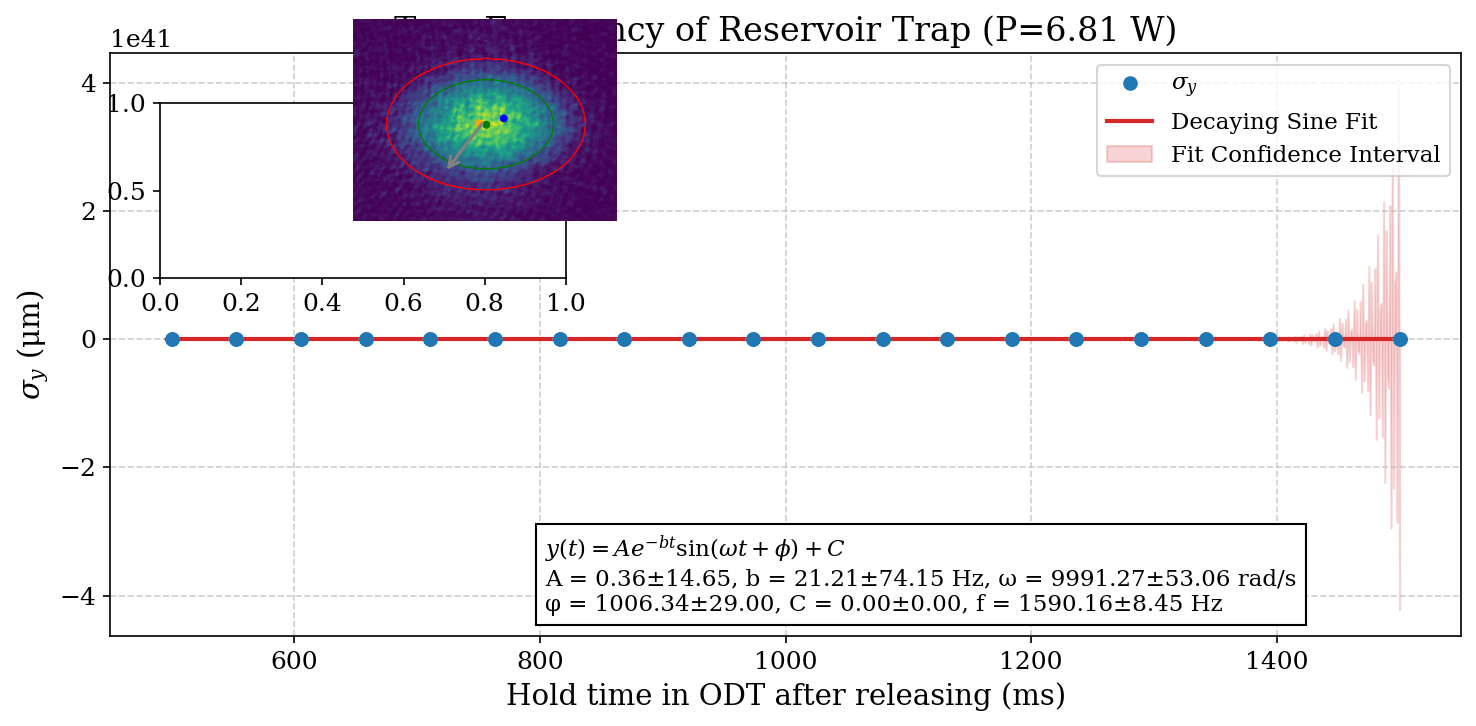

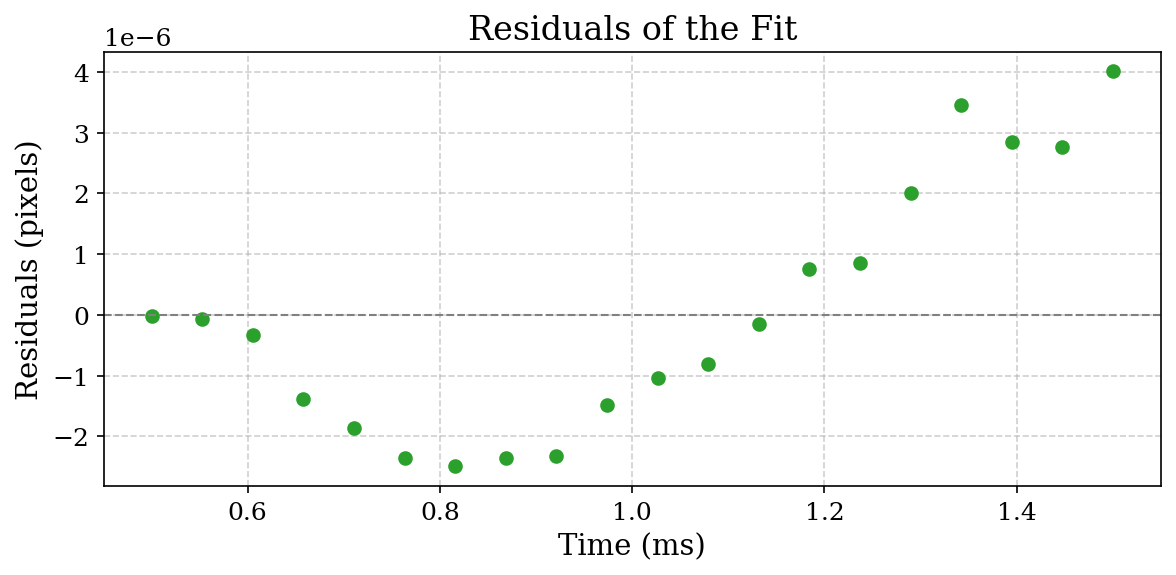

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib.offsetbox import AnchoredText
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl

from matplotlib.offsetbox import OffsetImage, AnnotationBbox


# show the euation of the fit in latex

inset = False
inset1 = False

dia_type = "y"

sy_mean = mean_std(Sy_set)[0]
sy_std = mean_std(Sy_set)[1]

# change them to numpy arrays
sy_mean = np.array(sy_mean)
sy_std = np.array(sy_std)


# define power from setpoint
def power(setpoint):
    gain = 14797.079958
    intercept = -584.871996
    return gain * setpoint + intercept


setpoint = 0.5
P = power(setpoint)
power_reservoir = np.round(P * 1e-3, 2)


fittype = "Diameter"


# if diameter then chnaged axis labels accordingly
if fittype == "Diameter":
    scale = 1e6
else:
    scale = 1.0


t_data = np.array(Scan_params_set[0] * 1e-3)  # Time data
d_data = np.array(sy_mean * scaling_factor)  # Centroid

print("Original Time data:", t_data)
print("Original Centroid data:", d_data)

# remove first point which is at t=0
# for i in range(len(t_data)):
#   if t_data[i]==0:
#       t_data = np.delete(t_data, i)
#       d_data = np.delete(d_data, i)
#       break


# remove last 20 points from both t_data_sorted and d_data_sorted
# t_data_sorted = t_data_sorted[:-20]
# d_data_sorted = d_data_sorted[:-20]

# DIVIDE d_data_sorted by 10
sorted_indices = np.argsort(t_data)
t_data_sorted = t_data[sorted_indices]
d_data_sorted = d_data[sorted_indices]


# print the sorted data
print("Sorted Time data:", t_data_sorted)
print("Sorted Diameter data:", d_data_sorted)

# remove last 10 points from both t_data_sorted and d_data_sorted
# t_data_sorted = t_data_sorted[:-10]
# d_data_sorted = d_data_sorted[:-10]


# Define the decaying sine function
def decaying_sine(t, A, b, omega, phi, C):
    return A * np.exp(-b * t) * np.sin(omega * t + phi) + C


# === Simulated or real data ===
# Replace with your actual t_data_sorted and d_data_sorted
# t_data_sorted = np.array([...])
# d_data_sorted = np.array([...])
# scale = 1  # e.g., pixels to microns
# fittype = "Diameter"
# power_reservoir = 4.3

# === Initial guess ===
initial_guess = [20.0, 50.0, 10000.0, 1000, np.mean(d_data_sorted)]

# === Plot style ===
mpl.rcParams.update(
    {
        "font.size": 12,
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "legend.fontsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "figure.dpi": 150,
        "lines.linewidth": 2,
        "lines.markersize": 6,
        "text.usetex": False,
    }
)

# === Curve fitting ===
popt, pcov = curve_fit(decaying_sine, t_data_sorted, d_data_sorted, p0=initial_guess)
A_fit, b_fit, omega_fit, phi_fit, C_fit = popt
frequency = omega_fit / (2 * np.pi)
perr = np.sqrt(np.diag(pcov))
delta_frequency = perr[2] / (2 * np.pi)

# === Generate fit curve ===
t_fit = np.linspace(min(t_data_sorted), max(t_data_sorted), 1000)
d_fit = decaying_sine(t_fit, *popt)

# === Main plot ===
fig, ax = plt.subplots(figsize=(10, 5))
if dia_type == "x":
    LABELDD = r"$\sigma_x$ "
else:
    LABELDD = r"$\sigma_y$ "

ax.plot(
    t_data_sorted * 1e3,
    d_data_sorted * scale,
    "o",
    label=LABELDD,
    color="tab:blue",
)
ax.plot(t_fit * 1e3, d_fit * scale, "-", label="Decaying Sine Fit", color="tab:red")

# === Labels and title ===
if fittype == "Diameter":
    ax.set_xlabel("Hold time in ODT after releasing (ms)")
    if dia_type == "x":
        ax.set_ylabel("$\sigma_x$ (μm)")
    else:
        ax.set_ylabel("$\sigma_y$ (μm)")
    ax.set_title(f"Trap Frequency of Reservoir Trap (P={power_reservoir} W)")
else:
    ax.set_xlabel("Hold time in Dipole Trap after releasing (ms)")
    ax.set_ylabel("Fitted Peak of Gaussian X (pixels)")
    ax.set_title(f"Trap Frequency Measurement (P={power_reservoir} W)")


# === Annotated fit parameters ===
fit_eq = r"$y(t) = Ae^{-bt} \sin(\omega t + \phi) + C$"
fit_params = (
    f"A = {A_fit:.2f}±{perr[0]:.2f}, b = {b_fit:.2f}±{perr[1]:.2f} Hz, "
    f"ω = {omega_fit:.2f}±{perr[2]:.2f} rad/s\n"
    f"φ = {phi_fit:.2f}±{perr[3]:.2f}, C = {C_fit:.2f}±{perr[4]:.2f}, "
    f"f = {frequency:.2f}±{delta_frequency:.2f} Hz"
)
# move little right

if dia_type == "x":
    at = AnchoredText(
        f"{fit_eq}\n{fit_params}",
        loc="upper center",
        frameon=True,
        prop=dict(size=11),
        bbox_to_anchor=(0.40, 1.0),  # x=0.5 is center, 0.55 moves it slightly right
        bbox_transform=ax.transAxes,  # anchor relative to axes
    )
else:
    at = AnchoredText(
        f"{fit_eq}\n{fit_params}",
        loc="lower center",
        frameon=True,
        prop=dict(size=11),
        bbox_to_anchor=(0.60, 0),  # x=0.5 is center, 0.55 moves it slightly right
        bbox_transform=ax.transAxes,  # anchor relative to axes
    )

ax.add_artist(at)

# error bars
ax.errorbar(
    t_data_sorted * 1e3,
    d_data_sorted * scale,
    yerr=sy_std * scaling_factor * scale,
    fmt="o",
    color="tab:blue",
    ecolor="grey",
    elinewidth=2,
    capsize=4,
)


if inset:
    # === Inset 1: Zoom on early oscillations ===
    axins1 = inset_axes(ax, width="30%", height="30%", loc="upper left", borderpad=2)
    axins1.plot(t_data_sorted * 1e3, d_data_sorted * scale, "o", color="tab:blue")
    axins1.plot(t_fit * 1e3, d_fit * scale, "-", color="tab:red")
    axins1.set_xlim(0, 1.5)
    axins1.set_ylim(min(d_fit * scale) * 0.95, max(d_fit * scale) * 1.05)
    axins1.set_xticks([])
    axins1.set_yticks([])
    axins1.set_title("Zoom: Initial Oscillations", fontsize=10)

    # === Inset 2: Zoom on envelope decay ===
    axins2 = inset_axes(ax, width="30%", height="30%", loc="upper right", borderpad=2)
    axins2.plot(
        t_fit * 1e3,
        A_fit * np.exp(-b_fit * t_fit) * scale + C_fit * scale,
        "--",
        color="tab:gray",
        label="Envelope",
    )
    axins2.plot(
        t_fit * 1e3,
        -A_fit * np.exp(-b_fit * t_fit) * scale + C_fit * scale,
        "--",
        color="tab:gray",
    )
    axins2.plot(t_data_sorted * 1e3, d_data_sorted * scale, "o", color="tab:blue")
    axins2.plot(t_fit * 1e3, d_fit * scale, "-", color="tab:red")
    axins2.set_xlim(0, max(t_data_sorted) * 1e3)
    axins2.set_ylim(min(d_fit * scale) * 0.95, max(d_fit * scale) * 1.05)
    axins2.set_xticks([])
    axins2.set_yticks([])
    axins2.set_title("Zoom: Envelope Decay", fontsize=10)


# add a external image to the plot pointing to one point on the curve in zoom inset 1
# using annotation box
path_image = "/home/ae19663/Downloads/GetImage.png"
if True:
    axins1 = inset_axes(ax, width="30%", height="30%", loc="upper left", borderpad=2)
    # Coordinates in data units of the inset where the image will be placed
    image_coords = (0.8, 0.9)  # You can adjust this for better positioning
    image_zoom = 0.3  # Resize factor

    # Load the image
    image = plt.imread(path_image)
    imagebox = OffsetImage(image, zoom=image_zoom)

    # Create annotation box for the image
    ab = AnnotationBbox(
        imagebox,
        xy=image_coords,  # where to place the image
        xycoords="data",  # use data coords of axins1
        frameon=False,
        box_alignment=(0.5, 0.5),
        pad=0,
    )

    # Add the image annotation box to axins1
    axins1.add_artist(ab)

    # Add arrow pointing from the image to a data point in axins1
    axins1.annotate(
        "",  # no text
        xy=(0.7, 0.6),  # data point you're pointing to
        xytext=image_coords,  # where the arrow starts (center of image)
        xycoords="data",
        textcoords="data",
        arrowprops=dict(arrowstyle="->", color="gray", lw=1.5),
    )

# plot the confidence interval
# Calculate the standard deviation of the fit
fit_std = np.sqrt(np.diag(pcov))
# Generate upper and lower bounds for the fit
d_fit_upper = decaying_sine(t_fit, *(popt + fit_std))
d_fit_lower = decaying_sine(t_fit, *(popt - fit_std))
# Fill the area between the upper and lower bounds
ax.fill_between(
    t_fit * 1e3,
    d_fit_lower * scale,
    d_fit_upper * scale,
    color="tab:red",
    alpha=0.2,
    label="Fit Confidence Interval",
)
plt.tight_layout()

if dia_type == "x":
    ax.legend(loc="lower right", fontsize=11)
else:
    ax.legend(loc="upper right", fontsize=11)
ax.grid(True, linestyle="--", alpha=0.6)


plt.show()

# === Residuals plot ===
residuals = d_data_sorted - decaying_sine(t_data_sorted, *popt)
plt.figure(figsize=(8, 4))
plt.plot(t_data_sorted, residuals, "o", color="tab:green")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Time (ms)")
plt.ylabel("Residuals (pixels)")
plt.title("Residuals of the Fit")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

Pixel data: [705.  709.  705.6 686.6 727.6 677.  682.8 700.6 626.  655.2 620.8 551.6
 601.6 570.  518.8 542.4 518.4 472.8 434.8 505.2]
TOF data: [ 500.11  552.71  605.41  658.01  710.61  763.31  815.91  868.51  921.21
  973.81 1026.41 1079.01 1131.71 1184.31 1236.91 1289.61 1342.21 1394.81
 1447.51 1500.11]
Sorted TOF data: [ 500.11  552.71  605.41  658.01  710.61  763.31  815.91  868.51  921.21
  973.81 1026.41 1079.01 1131.71 1184.31 1236.91 1289.61 1342.21 1394.81
 1447.51 1500.11]
Sorted Pixel data: [705.  709.  705.6 686.6 727.6 677.  682.8 700.6 626.  655.2 620.8 551.6
 601.6 570.  518.8 542.4 518.4 472.8 434.8 505.2]
y0 = -149.8203457 ± 12.6355106 pixels
s = 35761816655.5369263 ± 2630656238.4335923 μm


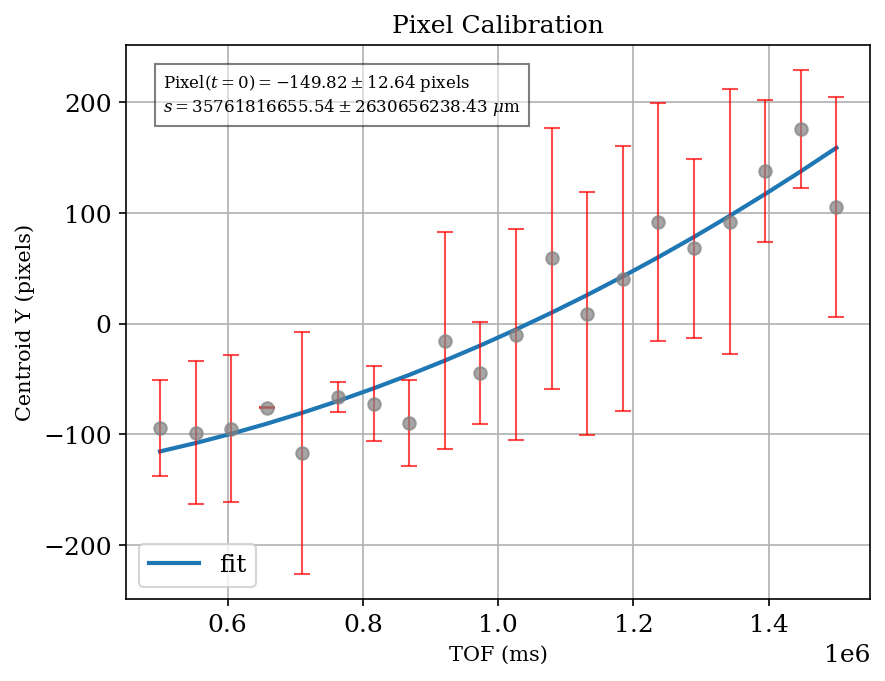

In [ ]:
# pixel calibration fit
g = 9.81  # m/s^2, gravitational acceleration

peakx_mean = mean_std(Peak_x_set)[0]
peakx_std = mean_std(Peak_x_set)[1]

try:
    t_data = Scan_params_set[
        0
    ]  # TOF data, assuming all sets have the same scan parameters
except IndexError:
    print("Error: Scan_params_set is empty. Please check the data extraction process.")
    t_data = []

pixel_number_vertical_data = np.array(
    peakx_mean
)  # Pixel data, using peakx as an example
print("Pixel data:", pixel_number_vertical_data)

print("TOF data:", t_data)


# increasing order t data
t_data_sorted = np.sort(t_data)
print("Sorted TOF data:", t_data_sorted)


# return index of some value in t_data_sorted
def get_index_of_value(value, t_data_sorted):
    try:
        return np.where(t_data_sorted == value)[0][0]
    except IndexError:
        return -1


# pixel data sorted
pixel_data_sorted = pixel_number_vertical_data[np.argsort(t_data)]
print("Sorted Pixel data:", pixel_data_sorted)

pixel_data_sorted = -(pixel_data_sorted - np.mean(pixel_data_sorted))


def model_pixel_calibration(t, y0, s):
    return y0 + (1 / 2) * t**2 * g / s


# Initial GUESS
y0_initial = 0.0
s_initial = 40e-6


# Fit your existing data
popt_pixel, pcov_pixel = curve_fit(
    model_pixel_calibration,
    t_data_sorted,
    pixel_data_sorted,
    p0=[y0_initial, s_initial],
)
y0_fit = popt_pixel[0]
y0_err = np.sqrt(np.diag(pcov_pixel))[0]
s_fit = popt_pixel[1]
s_err = np.sqrt(np.diag(pcov_pixel))[1]

# Print results
print(f"y0 = {y0_fit:.7f} ± {y0_err:.7f} pixels")
print(f"s = {s_fit * 1e6:.7f} ± {s_err * 1e6:.7f} μm")


# Plot pixel calibration
# plt.plot(t_data_sorted * 1e3, pixel_data_sorted, "o", label="data")
plt.plot(
    t_data_sorted * 1e3,
    model_pixel_calibration(t_data_sorted, *popt_pixel),
    label="fit",
)
# make the point size transparent

plt.xlabel("TOF (ms)", fontdict={"fontsize": 10, "family": "serif"})
plt.ylabel("Centroid Y (pixels)", fontdict={"fontsize": 10, "family": "serif"})
plt.legend()
plt.grid(True)

fit_text = (
    r"$\mathrm{Pixel}(t=0) = "
    + f"{y0_fit:.2f} \pm {y0_err:.2f}"
    + r"\ \mathrm{{pixels}}$"
    + "\n"
    + r"$s = "
    + f"{s_fit * 1e6:.2f} \pm {s_err * 1e6:.2f}"
    + r"\ \mu\mathrm{m}$"
)

plt.gca().text(
    0.05,
    0.95,
    fit_text,
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.5, edgecolor="black"),
    fontdict={"fontsize": 8, "family": "serif"},
)

plt.errorbar(
    t_data_sorted * 1e3,
    pixel_data_sorted,
    yerr=peakx_std,
    fmt="o",
    color="gray",
    ecolor="red",
    elinewidth=1,
    capsize=4,
    alpha=0.7,
)

# plt.tight_layout()
plt.title("Pixel Calibration", fontdict={"fontsize": 12, "family": "serif"})
plt.show()

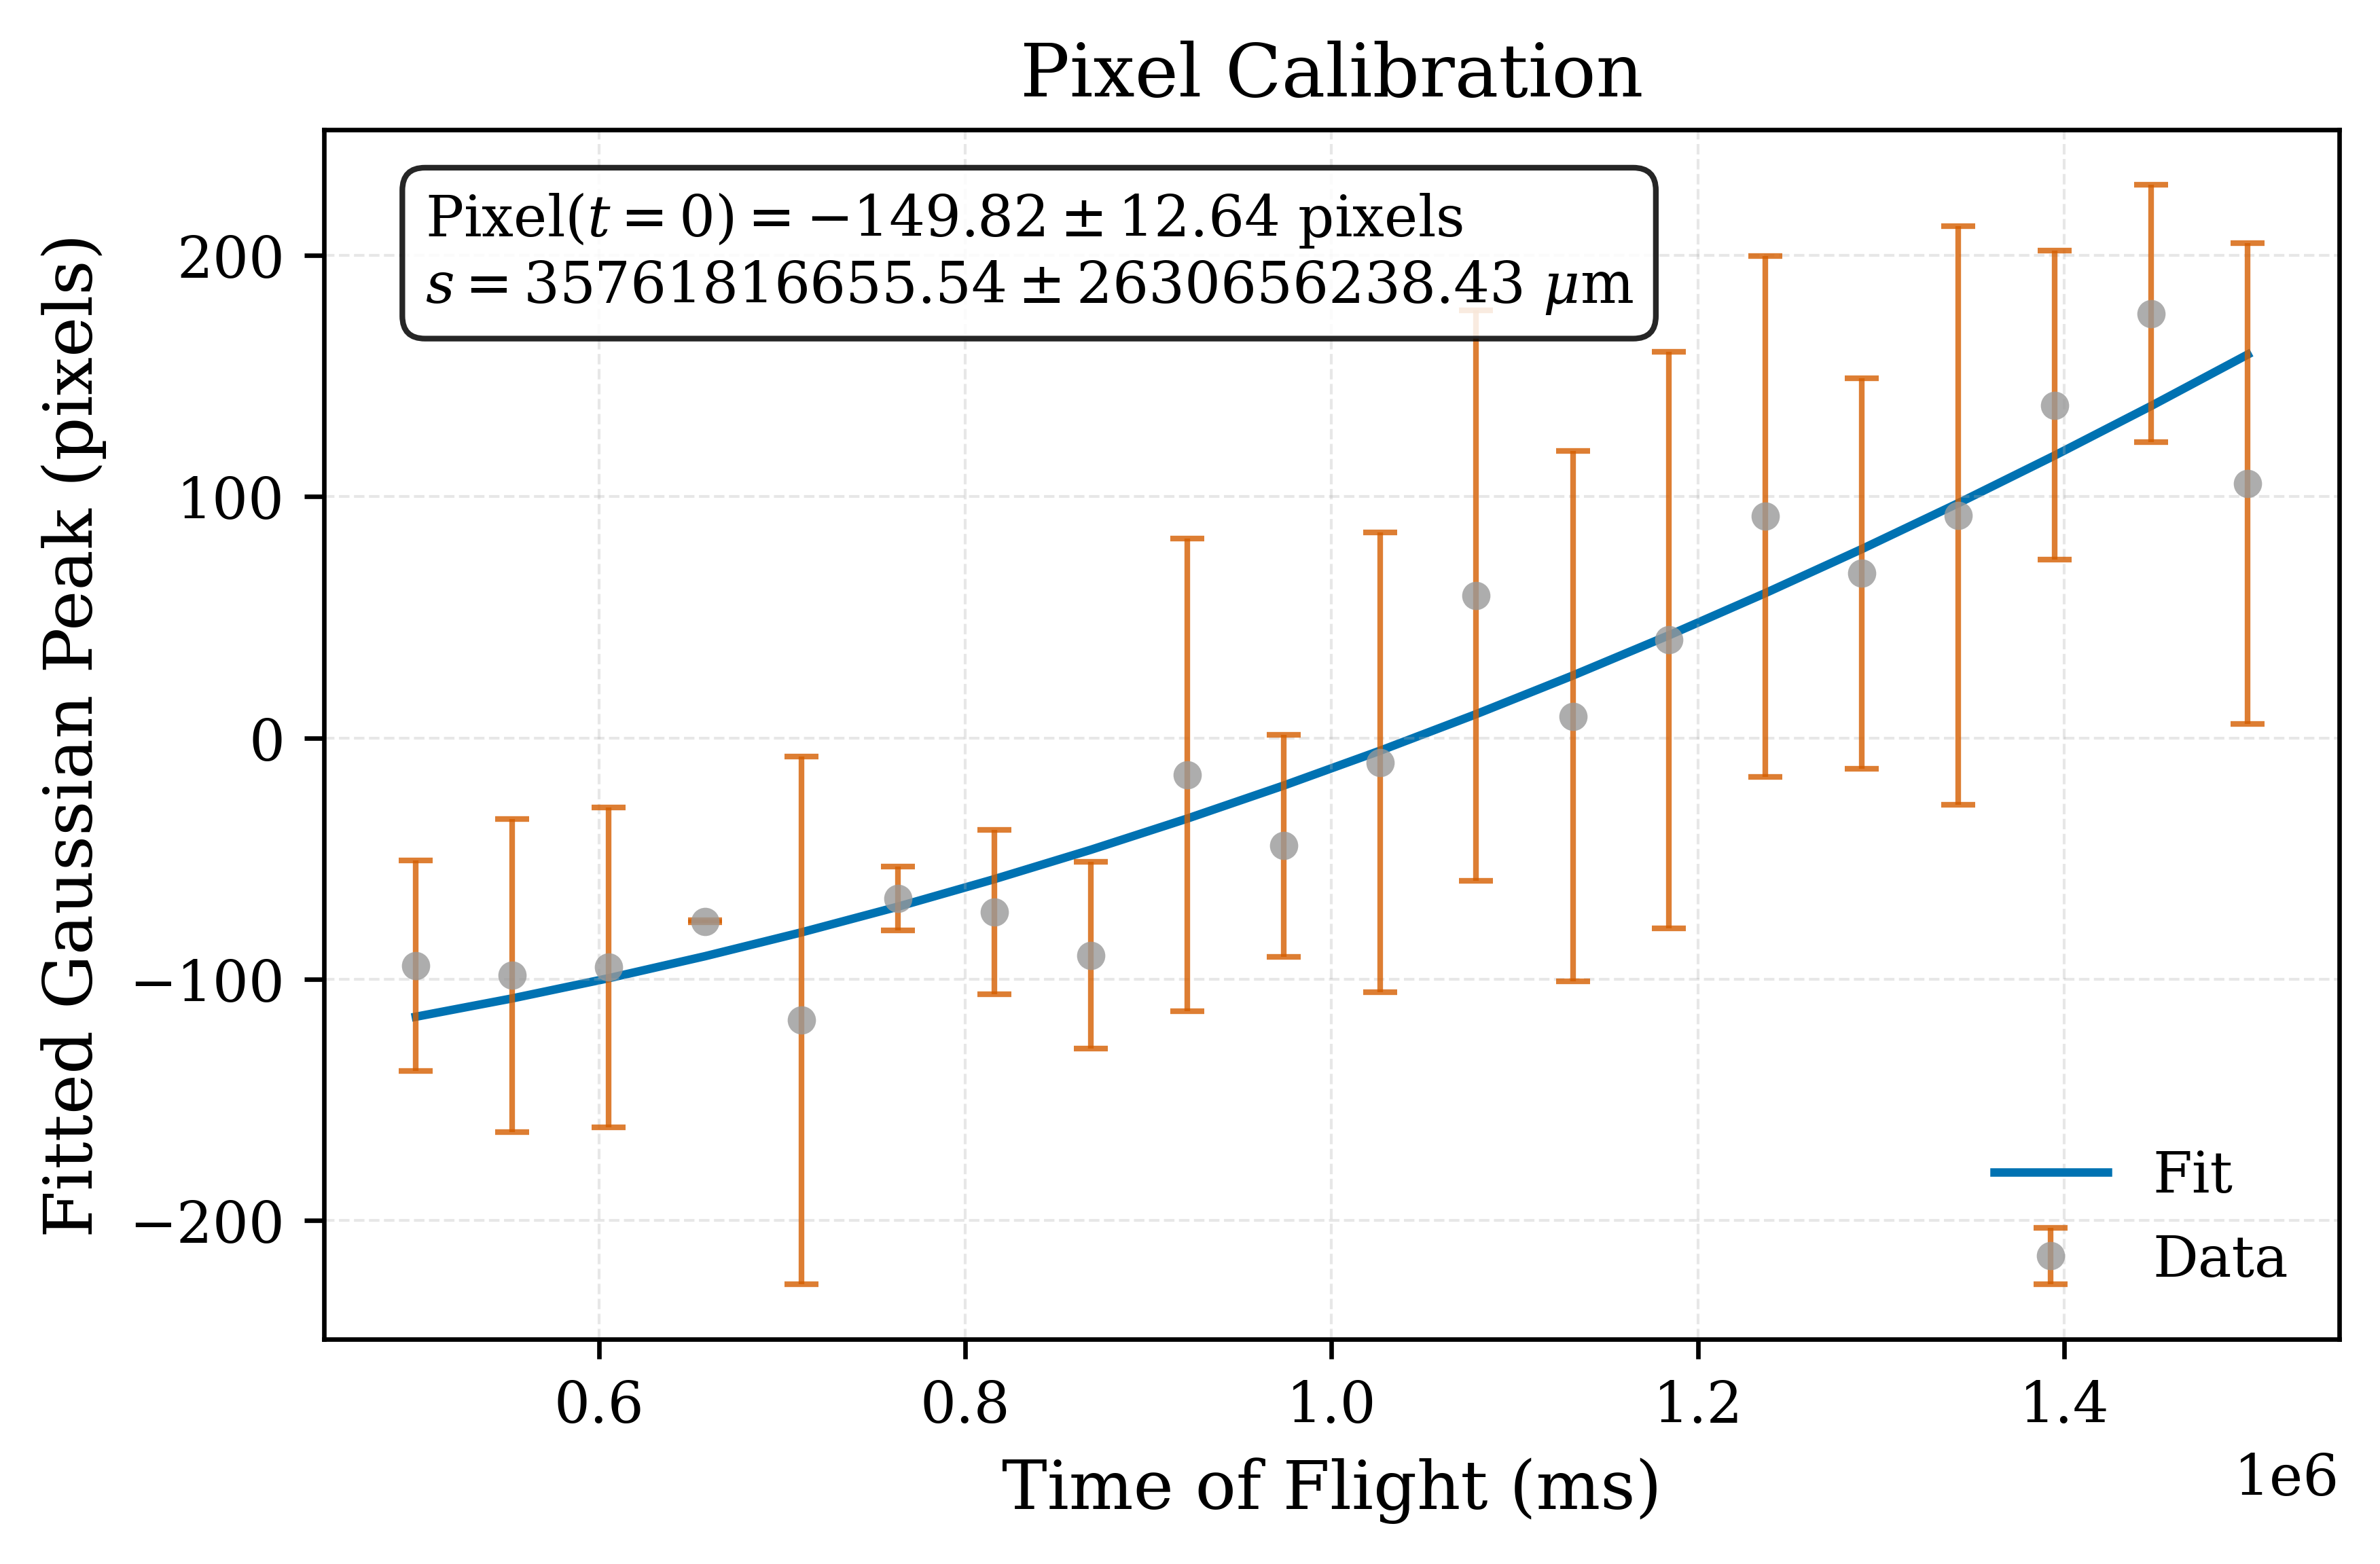

In [ ]:
import matplotlib.pyplot as plt

# Global style settings (without LaTeX)
plt.rcParams.update(
    {
        "font.family": "serif",
        "mathtext.fontset": "dejavuserif",  # serif math font
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "lines.linewidth": 1.5,
        "errorbar.capsize": 3,
    }
)

# Create high-resolution figure
fig, ax = plt.subplots(figsize=(6, 4), dpi=600)

# --- Fit Line ---
ax.plot(
    t_data_sorted * 1e3,
    model_pixel_calibration(t_data_sorted, *popt_pixel),
    color="#0072B2",  # Blue
    label="Fit",
    zorder=1,
)

# --- Data Points with Error Bars ---
ax.errorbar(
    t_data_sorted * 1e3,
    pixel_data_sorted,
    yerr=peakx_std,
    fmt="o",
    color="#999999",  # Light gray points
    ecolor="#D55E00",  # Reddish error bars
    markerfacecolor="#999999",
    markeredgecolor="none",
    alpha=0.8,
    markersize=5,
    linewidth=1,
    zorder=2,
    label="Data",
)

# --- Fit Text Annotation (Mathtext only) ---
fit_text = (
    r"$\mathrm{Pixel}(t{=}0) = "
    + f"{y0_fit:.2f} \pm {y0_err:.2f}"
    + r"\ \mathrm{pixels}$"
    + "\n"
    + r"$s = "
    + f"{s_fit * 1e6:.2f} \pm {s_err * 1e6:.2f}"
    + r"\ \mu\mathrm{m}$"
)

ax.text(
    0.05,
    0.95,
    fit_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(
        facecolor="white", edgecolor="black", boxstyle="round,pad=0.4", alpha=0.85
    ),
)

# --- Labels and Title ---
ax.set_xlabel("Time of Flight (ms)")
ax.set_ylabel("Fitted Gaussian Peak (pixels)")
ax.set_title("Pixel Calibration")

# --- Styling ---
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.3)
ax.legend(frameon=False, loc="best")
plt.tight_layout()

# --- Show or Save ---
# plt.savefig("pixel_calibration.png", dpi=600, bbox_inches='tight')
plt.show()

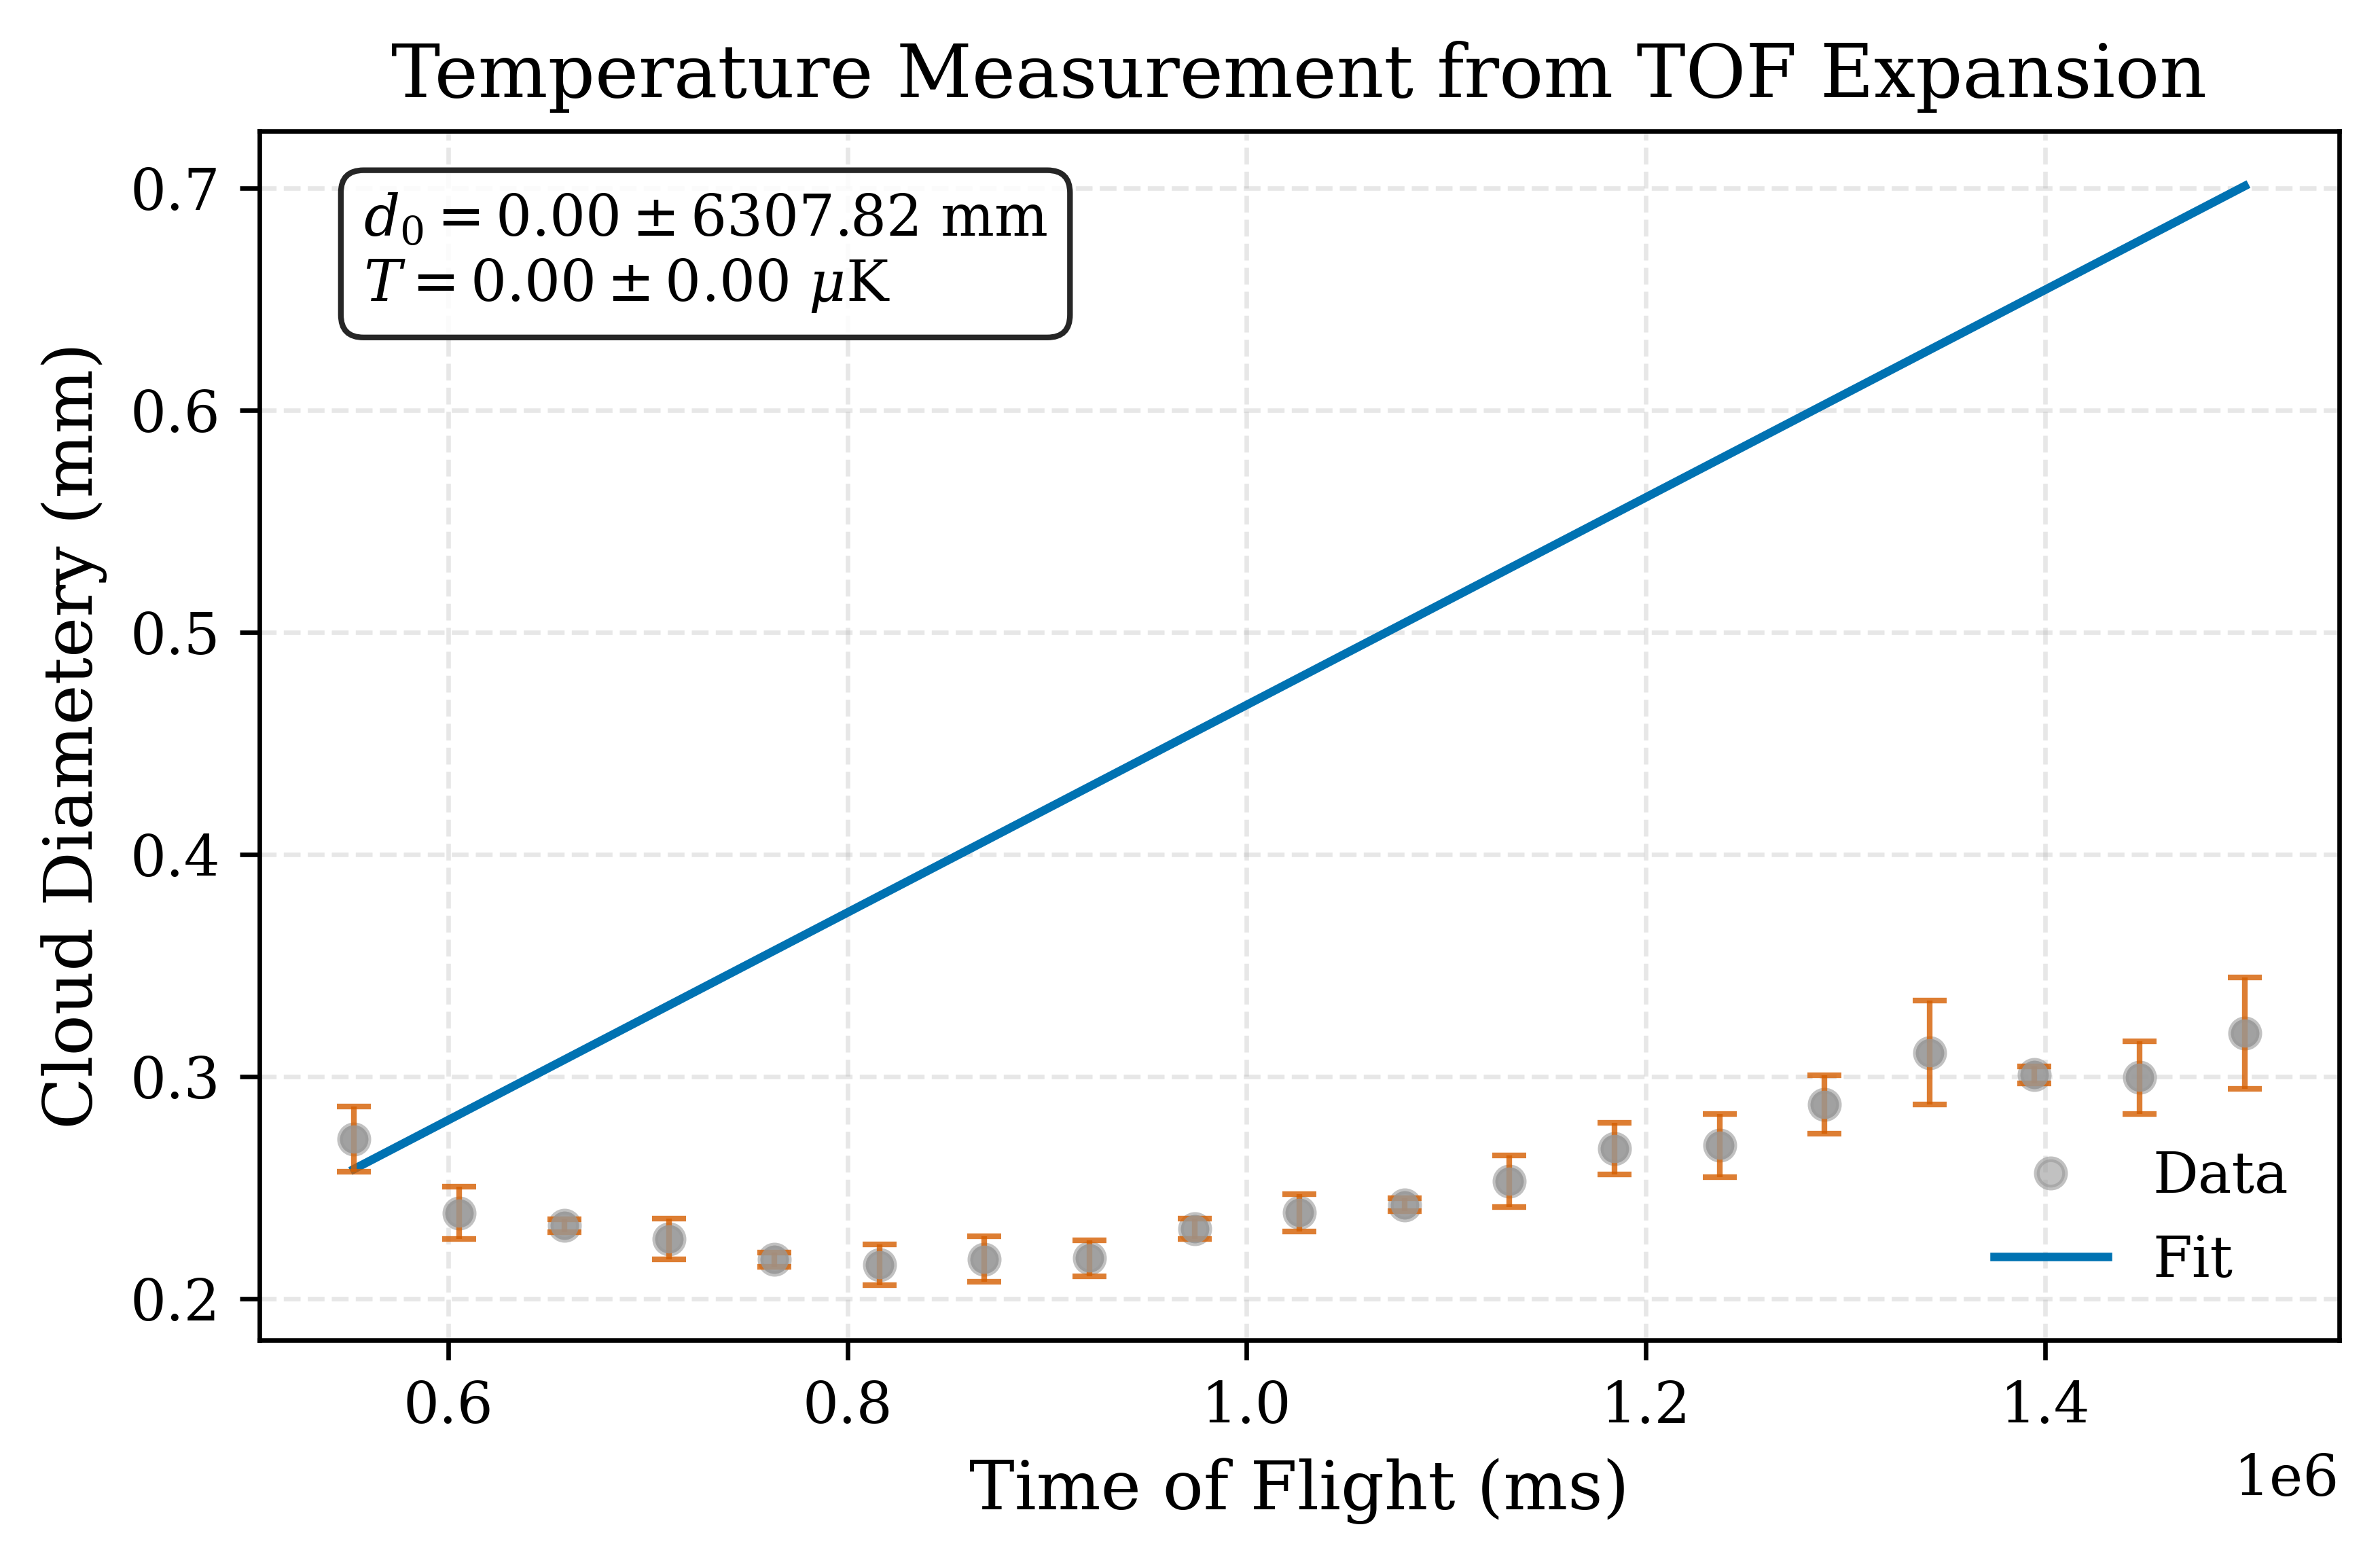

d₀ = 0.0000 ± 6307.8216 mm
T  = 0.0000 ± 0.0000 μK
Final temperature: 0.0000 ± 0.0000 μK


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ----------------------------
# Data (replace with yours)
# ----------------------------


diameter_data = Sy_set  # Measured diameters (pixels)

sy_mean = mean_std(diameter_data)[0]
sy_std = mean_std(diameter_data)[1]

physical_scale = 24.83e-6  # µm/pixel from pixel calibration
sy_mean = [i * physical_scale for i in sy_mean]  # Convert to meters
sy_std = [i * physical_scale for i in sy_std]  # Convert to meters

d_data = np.array(sy_mean)  # Measured diameters (m)

# Sort data
t_data_sorted = np.sort(t_data)
d_data_sorted = d_data[np.argsort(t_data)]

# remove the first data point (optional)
t_data_sorted = t_data_sorted[1:]
d_data_sorted = d_data_sorted[1:]
sy_mean = sy_mean[1:]
sy_std = sy_std[1:]

# ----------------------------
# ⚙️ Physics constants
# ----------------------------
kB = 1.380649e-23  # J/K
m = 1.45e-25  # Mass of atom (kg)


# ----------------------------
# Model: d(t) = sqrt(d0^2 + (kB*T/m)*t^2)
# ----------------------------
def model(t, d0, T):
    return np.sqrt(d0**2 + (kB * T * t**2) / m)


# Fit parameters
p0 = [2e-3, 100e-6]  # Initial guess: [d0 (m), T (K)]
bounds = ([0, 0], [np.inf, np.inf])
popt, pcov = curve_fit(model, t_data_sorted, d_data_sorted, p0=p0, bounds=bounds)

d0_fit, T_fit = popt
d0_err, T_err = np.sqrt(np.diag(pcov))

# ----------------------------
# 🎨 Plotting (Nature style)
# ----------------------------

# Plot style
plt.rcParams.update(
    {
        "font.family": "serif",
        "mathtext.fontset": "dejavuserif",
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "lines.linewidth": 1.5,
        "errorbar.capsize": 3,
    }
)

# Create figure
fig, ax = plt.subplots(figsize=(6, 4), dpi=600)

# --- Data Points ---
ax.plot(
    t_data_sorted * 1e3,
    d_data_sorted * 1e3,
    "o",
    color="#999999",
    markersize=5,
    alpha=0.6,
    label="Data",
)

# --- Fit Curve ---
ax.plot(
    t_data_sorted * 1e3, model(t_data_sorted, *popt) * 1e3, color="#0072B2", label="Fit"
)

# --- Fit Parameters Box ---
fit_text = (
    r"$d_0 = "
    + f"{d0_fit * 1e3:.2f} \pm {d0_err * 1e3:.2f}"
    + r"\ \mathrm{{mm}}$"
    + "\n"
    + r"$T = "
    + f"{T_fit * 1e6:.2f} \pm {T_err * 1e6:.2f}"
    + r"\ \mu\mathrm{{K}}$"
)

ax.text(
    0.05,
    0.95,
    fit_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(
        facecolor="white", edgecolor="black", boxstyle="round,pad=0.4", alpha=0.85
    ),
)

# --- Labels & Layout ---
ax.set_xlabel("Time of Flight (ms)")
ax.set_ylabel("Cloud Diametery (mm)")
ax.set_title("Temperature Measurement from TOF Expansion")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(frameon=False)
plt.tight_layout()


# multiply each element of sy_mean and sy_std with 1e3 to convert to mm
sy_mean = [i * 1e3 for i in sy_mean]
sy_std = [i * 1e3 for i in sy_std]

# error bars
ax.errorbar(
    t_data_sorted * 1e3,
    sy_mean,
    yerr=sy_std,
    fmt="o",
    color="#999999",  # Light gray points
    ecolor="#D55E00",  # Reddish error bars
    markerfacecolor="#999999",
    markeredgecolor="none",
    alpha=0.8,
    markersize=5,
    linewidth=1,
    zorder=2,
    label="Data",
)
plt.show()
# ----------------------------
# Final Output
# ----------------------------

print(f"d₀ = {d0_fit * 1e3:.4f} ± {d0_err * 1e3:.4f} mm")
print(f"T  = {T_fit * 1e6:.4f} ± {T_err * 1e6:.4f} μK")

# Pixel size calibration uncertainty
s = 28.19  # µm/pixel
delta_s = 10.59  # µm/pixel

delta_T_pixel = T_fit * 2 * (delta_s / s)
delta_T_total = np.sqrt(T_err**2 + delta_T_pixel**2)

print(f"Final temperature: {T_fit * 1e6:.4f} ± {delta_T_total * 1e6:.4f} μK")

In [ ]:
from scipy import constants as const


sigma_x = 0.36e-3  # in meters
# sigma_y = 0.36e-3  # in meters
sigma_z = 0.68e-3  # in meters
T = 30e-6  # in Kelvin
m = 1.443e-25  # in kg
Atom_number = 4e6  # Total number of atoms


def phase_space_density(self, sigma_x, sigma_z, T, m):
    """
    Calculate phase-space density for a thermal atomic cloud.

    Parameters
    ----------
    N : float
        Total number of atoms in the cloud.
    sigma_x, sigma_y, sigma_z : floats
        Position-space 1/e standard deviations (meters) along x, y, z.
    T : float
        Temperature in Kelvin.
    m : float
        Mass of one atom in kilograms.

    Returns
    -------
    n : float
        Number density (atoms per cubic meter).
    lambda_db : float
        Thermal de Broglie wavelength (meters).
    PSD : float
        Phase-space density (dimensionless, N λ³ / V).
    """

    # Volume of the cloud assuming Gaussian distribution, 3D
    # V = (2π)^(3/2) σx σy σz
    V = (2 * np.pi) ** (3 / 2) * sigma_x * sigma_x * sigma_z

    # Number density
    n = Atom_number / V

    # Thermal de Broglie wavelength
    # λ_dB = h / sqrt(2 π m k_B T)
    lambda_db = const.h / np.sqrt(2 * np.pi * m * const.k * T)

    # Phase-space density: n * λ_dB^3
    PSD = n * lambda_db**3

    return n, lambda_db, PSD


n, lambda_db, PSD = phase_space_density(sigma_x, sigma_x, sigma_z, T, m)
print(f"Number density: {n:.2e} atoms/m³")
print(f"Thermal de Broglie wavelength: {lambda_db:.2e} m")
print(f"Phase-space density: {PSD:.2e}")

Number density: 2.88e+15 atoms/m³
Thermal de Broglie wavelength: 3.42e-08 m
Phase-space density: 1.15e-07
